In [1]:
import pandas as pd

In [2]:
df = pd.read_excel(r"C:\Users\META\Documents\Desktop\Annual Trading Statistics.xlsx",sheet_name=None)

In [3]:
df.keys()

dict_keys(['2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008', '2007', '2006'])

In [4]:
# Check that required years exist
expected_years = set(str(y) for y in range(2006, 2023))
actual_years = set(df.keys())

missing_years = expected_years - actual_years
missing_years

set()

In [5]:
df['2006'].columns

Index(['Company Name', 'Symbol', 'Open (Rs.)', 'High (Rs.)', 'Low (Rs.)',
       'Close Price (Rs)', 'Trade_Volume', 'Share Volume', 'Turnover(Rs)'],
      dtype='object')

In [6]:
for year, yearly_df in df.items():

    # clean column names
    yearly_df.columns = (
        yearly_df.columns
        .str.strip()
        .str.replace(' ', '_')
        .str.replace('.', '', regex=False)
        .str.replace('Close_Price_', 'Close_', regex=False)
    )

In [7]:
# Standardize company symbols
for year, yearly_df in df.items():
    yearly_df['Symbol'] = (
        yearly_df['Symbol']
        .astype(str) # Converts everything to string
        .str.strip() # Remove spaces
        .str.upper() # Converts all text to uppercase
    )

In [8]:
# Create a set of companies for each year
company_sets = []

for year, yearly_df in df.items():
    companies = set(yearly_df['Symbol'].dropna()) # Removes missing values
    company_sets.append(companies)

In [9]:
# Companies common to all years
companies_all_years = set.intersection(*company_sets)

In [10]:
len(companies_all_years)

268

In [11]:
result_df = pd.DataFrame( sorted(companies_all_years), columns=['Symbol'] ) # This DataFrame was created to facilitate the inclusion of the GICS industry group information.
result_df.to_excel("GICS_Industries.xlsx", index=False)

In [12]:
gics_df = pd.read_excel(r"C:\Users\META\Documents\Desktop\GICS.xlsx") # The GICS industry group of each company was added
gics_df

,Symbol,GICS Industry Group
0,AAF.N0000,Diversified Financials
1,AAIC.N0000,Insurance
2,ABAN.N0000,Consumer Durables and Apparel
3,ABL.N0000,Banks
4,ACAP.N0000,Diversified Financials
...,...,...
263,VONE.N0000,Utilities
264,VPEL.N0000,Energy
265,WAPO.N0000,Diversified Financials
266,WATA.N0000,Food Beverage and Tobacco


In [13]:
# Aggregation
agg_dict = {
    'Company_Name': 'first',
    'Open_(Rs)': 'mean',
    'High_(Rs)': 'max',
    'Low_(Rs)': 'min',
    'Close_(Rs)': 'mean',
    'Trade_Volume': 'sum',
    'Share_Volume': 'sum',
    'Turnover(Rs)': 'sum'
}

In [14]:
all_years_data = []

for year, yearly_df in df.items():
    
        annual_df = (
            yearly_df
            .groupby('Symbol', as_index=False)
            .agg(agg_dict)
        )

        annual_df = annual_df[
            annual_df['Symbol'].isin(companies_all_years)
        ]

        # Add Year column
        annual_df['Year'] = int(year)

        # Merge GICS info
        annual_df = annual_df.merge(
            gics_df,
            on='Symbol',
            how='left'
        )

        all_years_data.append(annual_df)

In [15]:
merged_df = (pd.concat(all_years_data, ignore_index=True)
                .sort_values(['Year', 'Symbol'])
                .reset_index(drop=True)
)
merged_df.head()

,Symbol,Company_Name,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year,GICS Industry Group
0,AAF.N0000,ASIA ASSET FINANCE PLC,8.800,10.5,4.8,9.100,6852,23973946,1.996679e+08,2006,Diversified Financials
1,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,38.6,7.0,24.525,12723,116163974,4.030213e+09,2006,Insurance
2,ABAN.N0000,ABANS ELECTRICALS PLC,105.000,155.0,55.0,122.250,5268,1218770,1.319051e+08,2006,Consumer Durables and Apparel
3,ABL.N0000,AMANA BANK PLC,3.400,5.2,2.9,4.400,26972,413278826,1.671705e+09,2006,Banks
4,ACAP.N0000,ASIA CAPITAL PLC,10.950,18.5,4.6,12.300,16007,61193341,5.254512e+08,2006,Diversified Financials


In [16]:
merged_df.to_excel("final_merged_dataset.xlsx", index=False)

In [17]:
# Sum turnover across years per company
turnover_df = (
    merged_df
    .groupby(['GICS Industry Group', 'Symbol', 'Company_Name'], as_index=False)
    .agg({'Turnover(Rs)': 'sum'})
)

turnover_df

,GICS Industry Group,Symbol,Company_Name,Turnover(Rs)
0,Automobiles and Components,TYRE.N0000,KELANI TYRES PLC,6.128324e+10
1,Banks,ABL.N0000,AMANA BANK PLC,3.022294e+10
2,Banks,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,5.305608e+11
3,Banks,COMB.X0000,COMMERCIAL BANK OF CEYLON PLC,3.600994e+10
4,Banks,DFCC.N0000,DFCC BANK PLC,1.142321e+11
...,...,...,...,...
263,Utilities,HPFL.N0000,LOTUS HYDRO POWER PLC,3.944297e+09
264,Utilities,HPWR.N0000,RESUS ENERGY PLC,1.916279e+10
265,Utilities,PAP.N0000,PANASIAN POWER PLC,8.350760e+10
266,Utilities,VLL.N0000,VIDULLANKA PLC,1.443787e+10


In [18]:
idx = turnover_df.groupby('GICS Industry Group')['Turnover(Rs)'].idxmax()
top_companies = turnover_df.loc[idx].reset_index(drop=True)

In [19]:
top_companies

,GICS Industry Group,Symbol,Company_Name,Turnover(Rs)
0,Automobiles and Components,TYRE.N0000,KELANI TYRES PLC,6.128324e+10
1,Banks,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,5.305608e+11
2,Capital Goods,JKH.N0000,JOHN KEELLS HOLDINGS PLC,1.391821e+12
3,Commercial and Professional Services,CARE.N0000,PRINTCARE PLC,2.179442e+10
4,Consumer Durables and Apparel,MGT.N0000,HAYLEYS FABRIC PLC,1.975469e+11
5,Consumer Services,EDEN.N0000,EDEN HOTEL LANKA PLC,5.708993e+10
6,Diversified Financials,LOLC.N0000,L O L C HOLDINGS PLC,1.011919e+12
7,Energy,LIOC.N0000,LANKA IOC PLC,3.740259e+11
8,Food Beverage and Tobacco,BIL.N0000,BROWNS INVESTMENTS PLC,2.124689e+12
9,Food and Staples Retailing,CARG.N0000,CARGILLS (CEYLON) PLC,5.965543e+10


In [20]:
# Commercial Bank of Ceylon PLC

In [21]:
company_symbol = "COMB.N0000"

company_df = (
    merged_df[merged_df["Symbol"] == company_symbol]
    .sort_values("Year")
    .reset_index(drop=True)
)

company_df

,Symbol,Company_Name,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year,GICS Industry Group
0,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,192.50,50.0,135.45,90784,400718772,3.054671e+10,2006,Banks
1,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,250.00,50.0,113.95,91073,396948752,2.969530e+10,2007,Banks
2,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,149.75,50.0,73.95,91405,392857572,2.871475e+10,2008,Banks
3,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,192.00,50.0,135.20,99181,431418298,3.436070e+10,2009,Banks
4,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,284.00,50.0,90.45,98672,448660632,4.018135e+10,2010,Banks
5,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,284.00,50.0,90.45,98672,448660632,4.018135e+10,2011,Banks
6,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,117.125,119.50,50.0,91.95,103128,502137488,3.983461e+10,2012,Banks
7,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,99.500,126.00,50.0,100.65,104647,583517954,4.980476e+10,2013,Banks
8,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,108.600,179.90,50.0,125.95,103760,514345028,4.609420e+10,2014,Banks
9,COMB.N0000,COMMERCIAL BANK OF CEYLON PLC,96.000,96.00,50.0,80.90,85914,385016672,2.775914e+10,2015,Banks


In [22]:
company_df.describe()

,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year
count,17.000000,17.000000,17.000000,17.000000,17.000000,1.700000e+01,1.700000e+01,17.000000
mean,109.883824,158.820588,58.135294,97.423529,81646.588235,3.848227e+08,3.120946e+10,2014.000000
std,17.717633,64.257585,24.068780,29.819237,57212.570227,2.531017e+08,1.876196e+10,5.049752
min,79.100000,85.000000,48.700000,50.200000,11811.000000,9.614552e+07,6.470299e+09,2006.000000
25%,97.500000,115.900000,50.000000,80.900000,38690.000000,2.037215e+08,1.855291e+10,2010.000000
50%,117.125000,149.750000,50.000000,90.450000,91073.000000,3.969488e+08,2.969530e+10,2014.000000
75%,117.125000,192.000000,50.000000,125.950000,99181.000000,4.486606e+08,4.018135e+10,2018.000000
max,144.000000,284.000000,128.500000,145.000000,257742.000000,1.155050e+09,8.327741e+10,2022.000000


In [23]:
import matplotlib.pyplot as plt

Text(0.5, 0.98, 'Trading Activity Over Time')

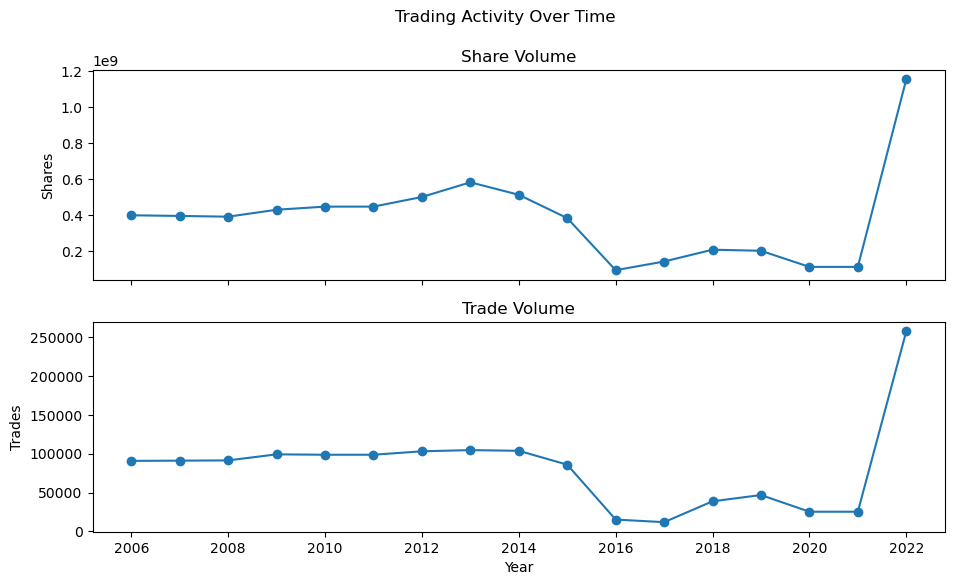

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(11,6), sharex=True)

axes[0].plot(
    company_df["Year"],
    company_df["Share_Volume"],
    marker='o'
)
axes[0].set_title("Share Volume")
axes[0].set_ylabel("Shares")

axes[1].plot(
    company_df["Year"],
    company_df["Trade_Volume"],
    marker='o'
)
axes[1].set_title("Trade Volume")
axes[1].set_ylabel("Trades")
axes[1].set_xlabel("Year")

fig.suptitle(
    "Trading Activity Over Time"
)

Text(2021, 50000000000.0, 'Expansion \nPhase')

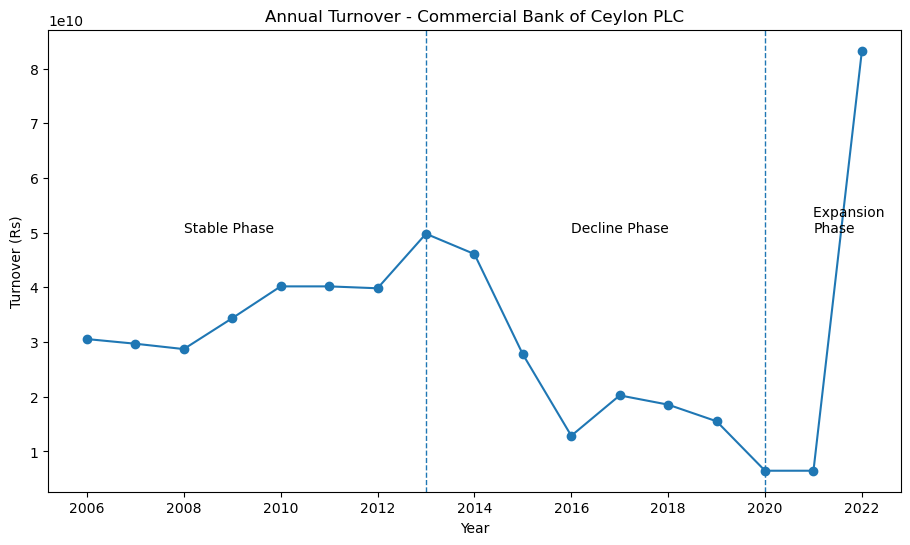

In [25]:
# Annual Turnover
plt.figure(figsize=(11,6))
plt.plot(company_df["Year"], company_df["Turnover(Rs)"], marker='o')
plt.xlabel("Year")
plt.ylabel("Turnover (Rs)")
plt.title("Annual Turnover - Commercial Bank of Ceylon PLC")

# Phase boundaries
plt.axvline(2013, linestyle='--', linewidth=1)
plt.axvline(2020, linestyle='--', linewidth=1)

# Phase annotations
plt.text(2008, 5e10, "Stable Phase", fontsize=10)
plt.text(2016, 5e10, "Decline Phase", fontsize=10)
plt.text(2021, 5e10, "Expansion \nPhase", fontsize=10)

Text(0.5, 0, 'Share Volume')

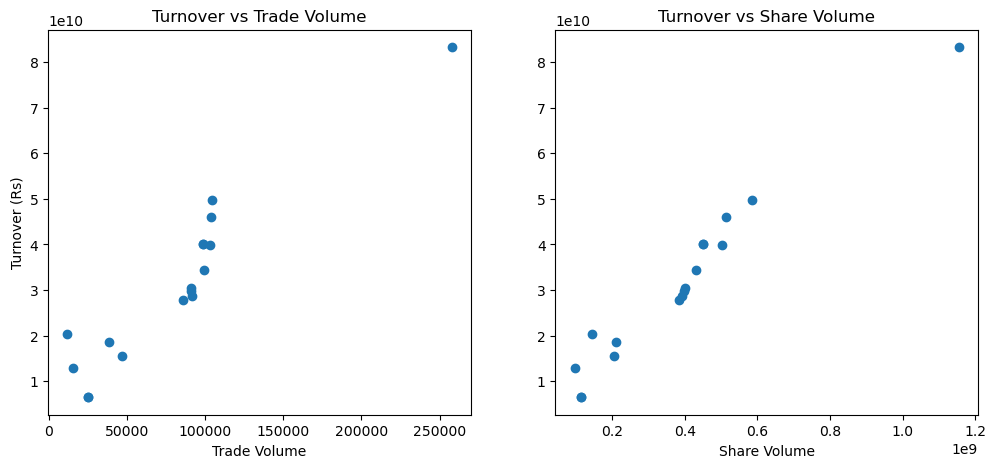

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(
    company_df["Trade_Volume"],
    company_df["Turnover(Rs)"],
)
axes[0].set_title("Turnover vs Trade Volume")
axes[0].set_xlabel("Trade Volume")
axes[0].set_ylabel("Turnover (Rs)")

axes[1].scatter(
    company_df["Share_Volume"],
    company_df["Turnover(Rs)"]
)
axes[1].set_title("Turnover vs Share Volume")
axes[1].set_xlabel("Share Volume")

Text(0.5, 1.0, 'Year-to-Year Turnover Growth')

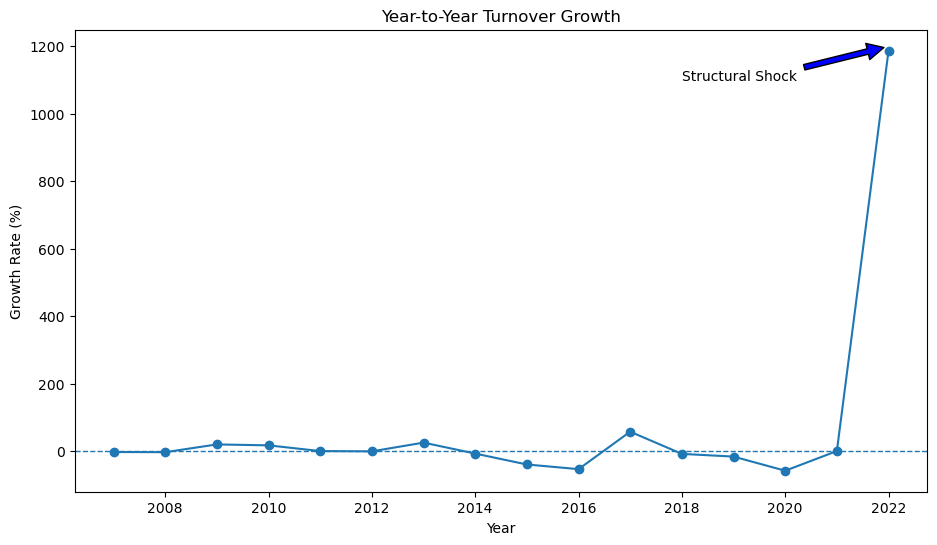

In [27]:
company_df["Turnover_Growth_%"] = (
    company_df["Turnover(Rs)"].pct_change() * 100
)

plt.figure(figsize=(11,6))
plt.plot(company_df["Year"], company_df["Turnover_Growth_%"], marker='o')
plt.annotate('Structural Shock', xy=(2022,1200), xytext=(2018,1100), arrowprops=dict(facecolor='b', shrink=0.05))
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("Year-to-Year Turnover Growth")

In [28]:
company_df["Turnover_Growth_%"]

0             NaN
1       -2.787237
2       -3.302032
3       19.662172
4       16.939853
5        0.000000
6       -0.862935
7       25.028860
8       -7.450207
9      -39.777374
10     -53.678796
11      57.456233
12      -8.363952
13     -16.388598
14     -58.289361
15       0.000000
16    1187.072044
Name: Turnover_Growth_%, dtype: float64

In [29]:
# Phases according to the annual turnover across years
def assign_phase(year):
    if year < 2013:
        return "Phase 1: Stable"
    elif year < 2020:
        return "Phase 2: Decline"
    else:
        return "Phase 3: Expansion"

company_df["Phase"] = company_df["Year"].apply(assign_phase)

In [30]:
growth_summary = (
    company_df
    .groupby("Phase")["Turnover_Growth_%"]
    .agg(["mean", "std", "min", "max", "count"])
)

growth_summary

,mean,std,min,max,count
Phase,,,,,
Phase 1: Stable,4.941637,10.454260,-3.302032,19.662172,6
Phase 2: Decline,-6.167690,37.680852,-53.678796,57.456233,7
Phase 3: Expansion,376.260895,702.787630,-58.289361,1187.072044,3


In [31]:
# Kruskal-Wallis
'''
H₀: The distribution of turnover growth rates is the same across all market phases.
H₁: At least one market phase has a significantly different turnover growth distribution.
'''

'\nH₀: The distribution of turnover growth rates is the same across all market phases.\nH₁: At least one market phase has a significantly different turnover growth distribution.\n'

In [32]:
from scipy.stats import kruskal

In [33]:
# Remove NaN values (first year has no growth rate)
kw_data = company_df.dropna(subset=["Turnover_Growth_%"])

# Split turnover growth by phase
stable = kw_data.loc[
    kw_data["Phase"] == "Phase 1: Stable",
    "Turnover_Growth_%"
]

decline = kw_data.loc[
    kw_data["Phase"] == "Phase 2: Decline",
    "Turnover_Growth_%"
]

expansion = kw_data.loc[
    kw_data["Phase"] == "Phase 3: Expansion",
    "Turnover_Growth_%"
]

In [34]:
kw_stat, p_value = kruskal(stable, decline, expansion)

print(f"Kruskal–Wallis H statistic: {kw_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Kruskal–Wallis H statistic: 1.287
P-value: 0.5255


Text(0.5, 1.0, 'Price Volatility (High–Low Range)')

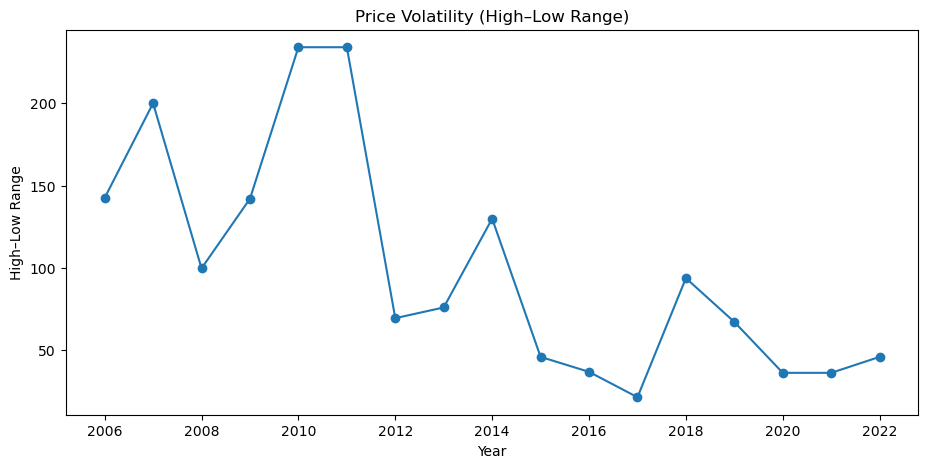

In [35]:
company_df["High_Low_Range"] = (
    company_df["High_(Rs)"] - company_df["Low_(Rs)"]
)

plt.figure(figsize=(11,5))
plt.plot(company_df["Year"], company_df["High_Low_Range"], marker='o')
plt.xlabel("Year")
plt.ylabel("High–Low Range")
plt.title("Price Volatility (High–Low Range)")

In [36]:
import seaborn as sns

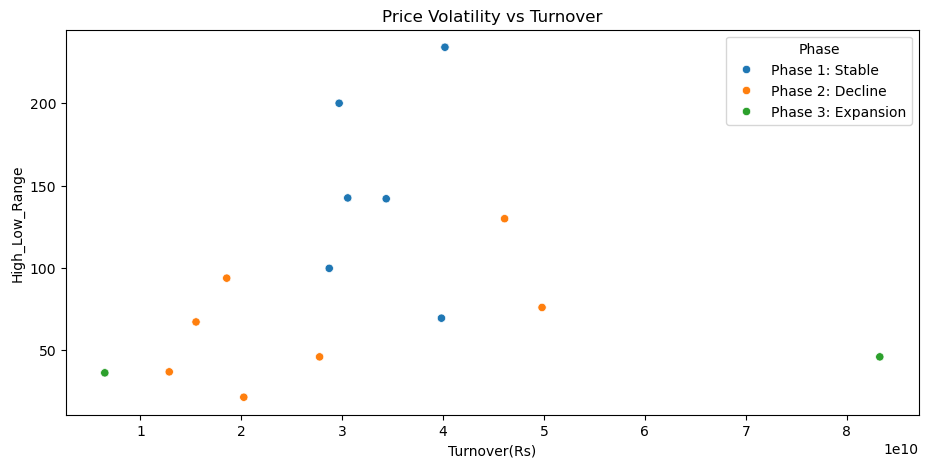

In [37]:
# Volatility vs Turnover
plt.figure(figsize=(11,5))
sns.scatterplot(data=company_df, x='Turnover(Rs)', y='High_Low_Range', hue='Phase')
plt.title("Price Volatility vs Turnover")
plt.show()

Text(0.5, 1.0, 'Price Volatility vs Share Volume')

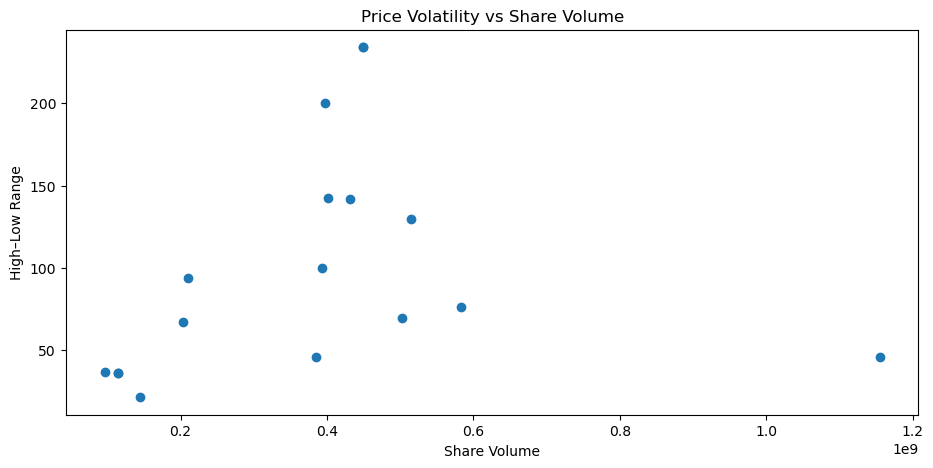

In [38]:
# Volatility vs Share Volume
plt.figure(figsize=(11,5))
plt.scatter(company_df["Share_Volume"], company_df["High_Low_Range"])
plt.xlabel("Share Volume")
plt.ylabel("High–Low Range")
plt.title("Price Volatility vs Share Volume")

Text(0.5, 1.0, 'Price Volatility vs Trade Volume')

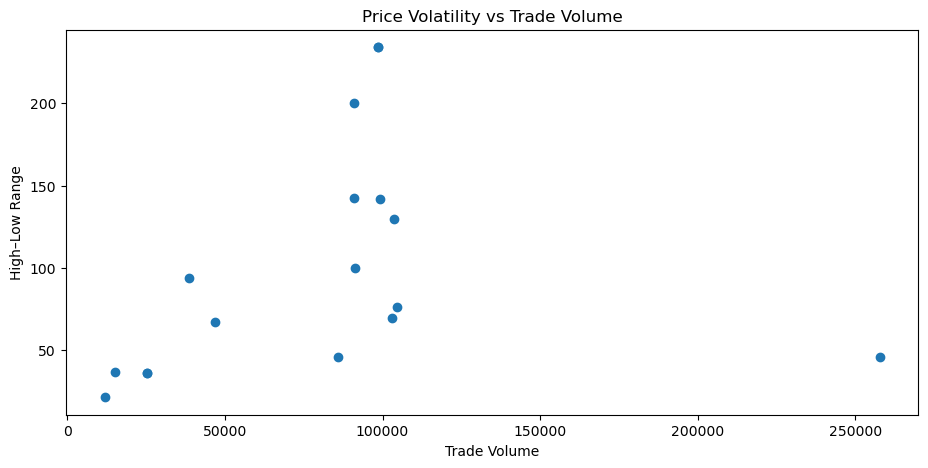

In [39]:
# Volatility vs Trade Volume
plt.figure(figsize=(11,5))
plt.scatter(company_df["Trade_Volume"], company_df["High_Low_Range"])
plt.xlabel("Trade Volume")
plt.ylabel("High–Low Range")
plt.title("Price Volatility vs Trade Volume")

In [40]:
from scipy.stats import pearsonr, spearmanr

In [41]:
variables = ["Turnover(Rs)", "Share_Volume", "Trade_Volume"]

for var in variables:
    pearson_corr, _ = pearsonr(company_df[var], company_df["High_Low_Range"])
    spearman_corr, _ = spearmanr(company_df[var], company_df["High_Low_Range"])
    
    print(f"{var}:")
    print(f"  Pearson correlation  = {pearson_corr:.3f}")
    print(f"  Spearman correlation = {spearman_corr:.3f}\n")

Turnover(Rs):
  Pearson correlation  = 0.251
  Spearman correlation = 0.565

Share_Volume:
  Pearson correlation  = 0.190
  Spearman correlation = 0.553

Trade_Volume:
  Pearson correlation  = 0.230
  Spearman correlation = 0.529



In [42]:
model_df = company_df.copy()

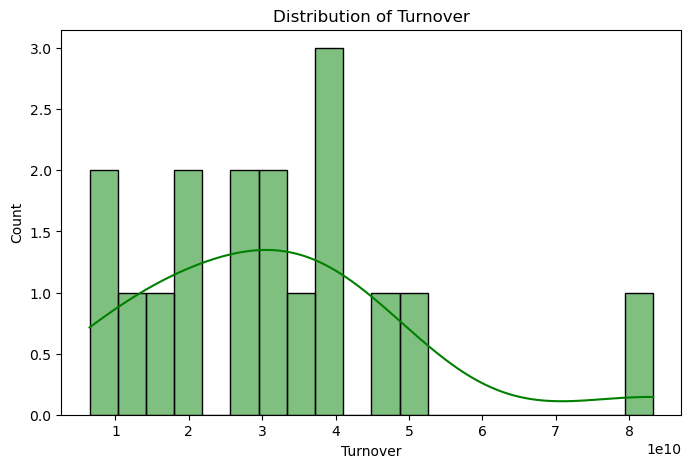

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(
    model_df["Turnover(Rs)"],
    bins=20,
    kde=True,
    color='g'
)
plt.xlabel("Turnover")
plt.title("Distribution of Turnover")
plt.show()

In [44]:
import numpy as np

In [45]:
# Log-transform turnover
model_df["Log_Turnover"] = np.log(model_df["Turnover(Rs)"])

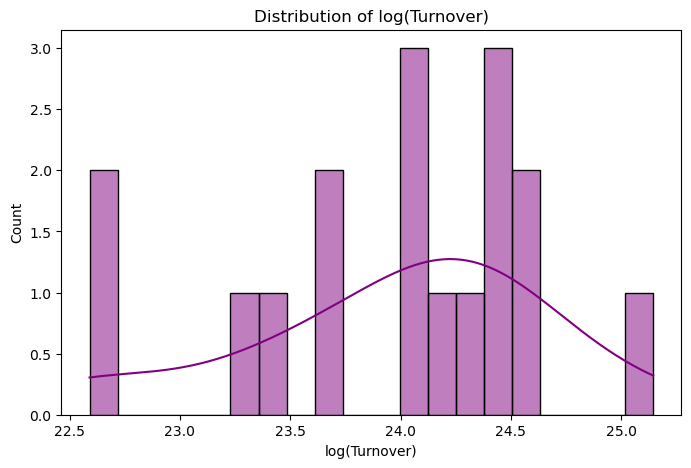

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(
    model_df["Log_Turnover"],
    bins=20,
    kde=True,
    color='purple'
)
plt.xlabel("log(Turnover)")
plt.title("Distribution of log(Turnover)")
plt.show()

In [47]:
import statsmodels.api as sm

In [48]:
# Create dummy variables for Phase
phase_dummies = pd.get_dummies(
    model_df["Phase"],
    drop_first=True,
    dtype=float
)

X = pd.concat([
    model_df[["High_Low_Range", "Share_Volume", "Trade_Volume"]],
    phase_dummies
], axis=1)

# Add intercept
X = sm.add_constant(X)

# Define response
y = model_df["Log_Turnover"]

In [49]:
# Align X and y and drop NaNs 
model_data = pd.concat([X, y], axis=1).dropna()

In [50]:
X = model_data[X.columns] 
y = model_data[y.name]

In [51]:
# Fit robust linear model
rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT())
rlm_results = rlm_model.fit()

print(rlm_results.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:           Log_Turnover   No. Observations:                   17
Model:                            RLM   Df Residuals:                       11
Method:                          IRLS   Df Model:                            5
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Mon, 02 Feb 2026                                         
Time:                        18:28:30                                         
No. Iterations:                    50                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 23.0312      0

In [52]:
# Residual Diagnostics
residuals = rlm_results.resid
fitted = rlm_results.fittedvalues

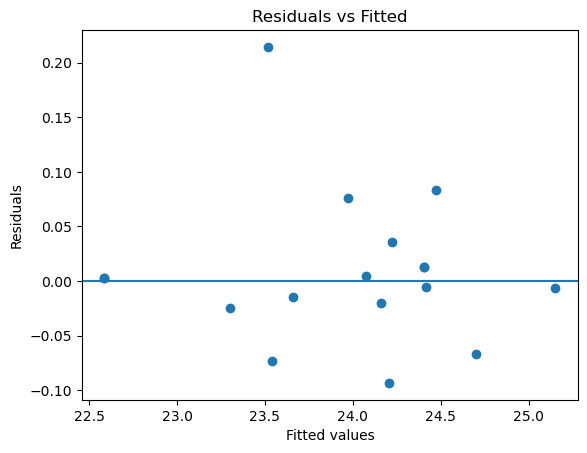

In [53]:
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

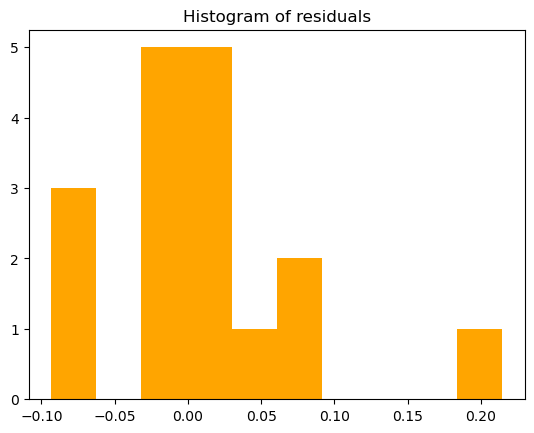

In [54]:
plt.hist(residuals, bins=10, color='orange')
plt.title("Histogram of residuals")
plt.show()

In [55]:
# SOFTLOGIC LIFE INSURANCE PLC

In [56]:
company_symbol2 = "AAIC.N0000"

company_df2 = (
    merged_df[merged_df["Symbol"] == company_symbol2]
    .sort_values("Year")
    .reset_index(drop=True)
)

company_df2

,Symbol,Company_Name,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year,GICS Industry Group
0,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,38.60,7.0,24.525,12723,116163974,4.030213e+09,2006,Insurance
1,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,50.00,13.5,37.275,12543,117544874,4.143173e+09,2007,Insurance
2,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,44.50,20.0,32.400,9738,109116774,3.942571e+09,2008,Insurance
3,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,59.75,20.0,45.400,9955,111849674,4.081544e+09,2009,Insurance
4,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,405.00,20.0,100.750,19922,146173990,9.126195e+09,2010,Insurance
5,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,405.00,20.0,100.750,19922,146173990,9.126195e+09,2011,Insurance
6,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,23.675,181.00,20.0,61.900,13070,110791505,4.106089e+09,2012,Insurance
7,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,63.800,107.00,20.0,60.150,11635,124950698,5.928412e+09,2013,Insurance
8,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,62.750,163.00,20.0,88.900,11264,110640105,4.164375e+09,2014,Insurance
9,AAIC.N0000,SOFTLOGIC LIFE INSURANCE PLC,38.600,38.60,20.0,34.800,9325,108892374,3.934774e+09,2015,Insurance


In [57]:
company_df2.describe()

,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year
count,17.000000,17.000000,17.000000,17.000000,17.000000,1.700000e+01,1.700000e+01,17.000000
mean,38.189706,151.526471,19.588235,56.723529,46475.352941,1.348653e+08,7.807469e+09,2014.000000
std,19.321996,129.957827,5.127241,27.967249,62544.434948,6.995431e+07,5.909848e+09,5.049752
min,16.000000,24.000000,7.000000,20.700000,2950.000000,1.316081e+07,2.539520e+08,2006.000000
25%,23.675000,38.600000,20.000000,34.800000,9955.000000,1.106401e+08,4.030213e+09,2010.000000
50%,23.675000,107.000000,20.000000,60.150000,12723.000000,1.175449e+08,4.164375e+09,2014.000000
75%,57.500000,249.000000,20.000000,86.600000,27975.000000,1.554747e+08,1.180432e+10,2018.000000
max,70.000000,405.000000,27.000000,100.750000,159642.000000,3.266771e+08,1.872542e+10,2022.000000


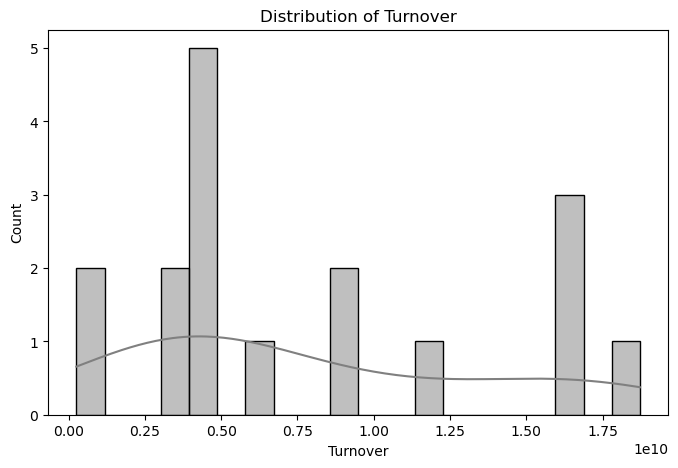

In [58]:
model_df2 = company_df2.copy()
plt.figure(figsize=(8,5))
sns.histplot(
    model_df2["Turnover(Rs)"],
    bins=20,
    kde=True,
    color='grey'
)
plt.xlabel("Turnover")
plt.title("Distribution of Turnover")
plt.show()

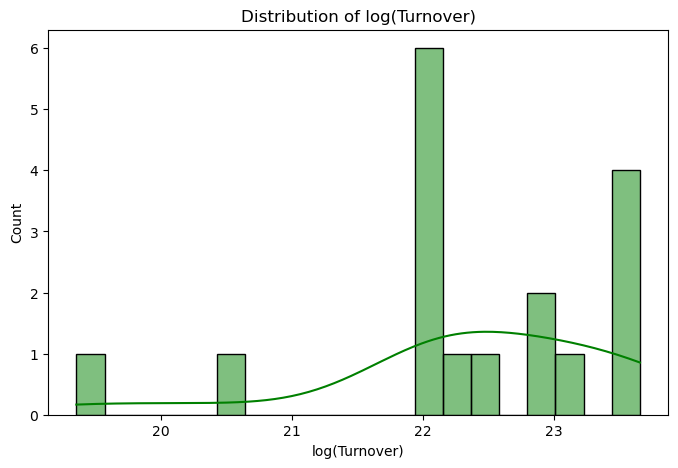

In [59]:
# Log-transform turnover
model_df2["Log_Turnover"] = np.log(model_df2["Turnover(Rs)"])
plt.figure(figsize=(8,5))
sns.histplot(
    model_df2["Log_Turnover"],
    bins=20,
    kde=True,
    color='g'
)
plt.xlabel("log(Turnover)")
plt.title("Distribution of log(Turnover)")
plt.show()

Text(2019, 5000000000.0, 'Expansion Phase')

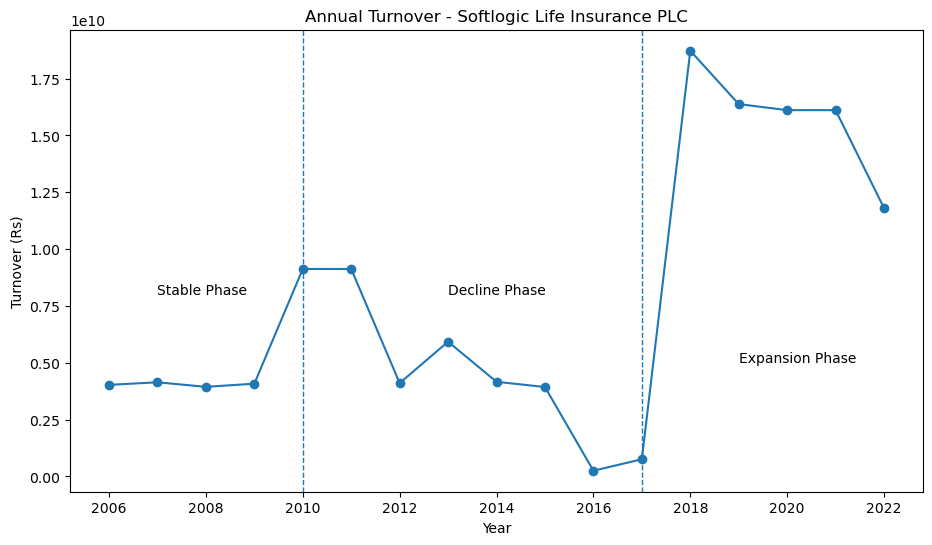

In [60]:
# Annual Turnover
plt.figure(figsize=(11,6))
plt.plot(company_df2["Year"], company_df2["Turnover(Rs)"], marker='o')
plt.xlabel("Year")
plt.ylabel("Turnover (Rs)")
plt.title("Annual Turnover - Softlogic Life Insurance PLC")

# Phase boundaries
plt.axvline(2010, linestyle='--', linewidth=1)
plt.axvline(2017, linestyle='--', linewidth=1)

# Phase annotations
plt.text(2007, 8e9, "Stable Phase", fontsize=10)
plt.text(2013, 8e9, "Decline Phase", fontsize=10)
plt.text(2019, 5e9, "Expansion Phase", fontsize=10)


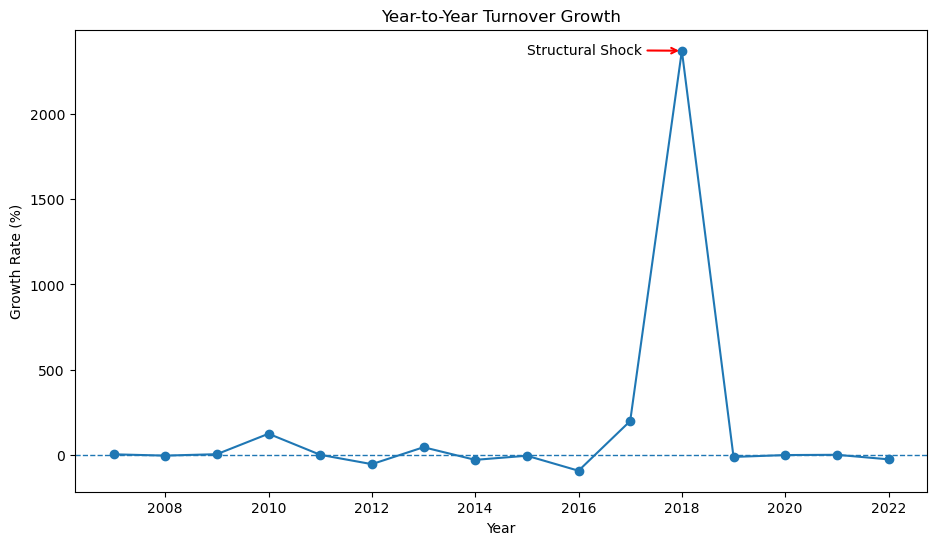

In [61]:
# Calculate growth
company_df2["Turnover_Growth_%"] = (
    company_df2["Turnover(Rs)"].pct_change() * 100
)

# Find highest growth point
max_idx = company_df2["Turnover_Growth_%"].idxmax()
max_growth = company_df2.loc[max_idx, "Turnover_Growth_%"]

plt.figure(figsize=(11,6))
plt.plot(company_df2["Year"], company_df2["Turnover_Growth_%"], marker='o')

# Annotation with visible arrow head
plt.annotate(
    'Structural Shock',
    xy=(2018, max_growth),              
    xytext=(2018 - 3, max_growth - 20), 
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color="red"
    )
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("Year-to-Year Turnover Growth")

plt.show()

In [62]:
# Phases according to the annual turnover across years
def assign_phase2(year):
    if year <= 2011:
        return "Phase 1: Stable"
    elif year <= 2017:
        return "Phase 2: Decline"
    else:
        return "Phase 3: Expansion"

company_df2["Phase"] = company_df2["Year"].apply(assign_phase2)

In [63]:
growth_summary2 = (
    company_df2
    .groupby("Phase")["Turnover_Growth_%"]
    .agg(["mean", "std", "min", "max", "count"])
)

growth_summary2

,mean,std,min,max,count
Phase,,,,,
Phase 1: Stable,25.016533,55.205797,-4.841733,123.596649,5
Phase 2: Decline,9.797268,103.324267,-93.545956,198.225335,6
Phase 3: Expansion,466.319700,1065.637571,-26.736439,2372.494348,5


Text(0.5, 0.98, 'Trading Activity Over Time')

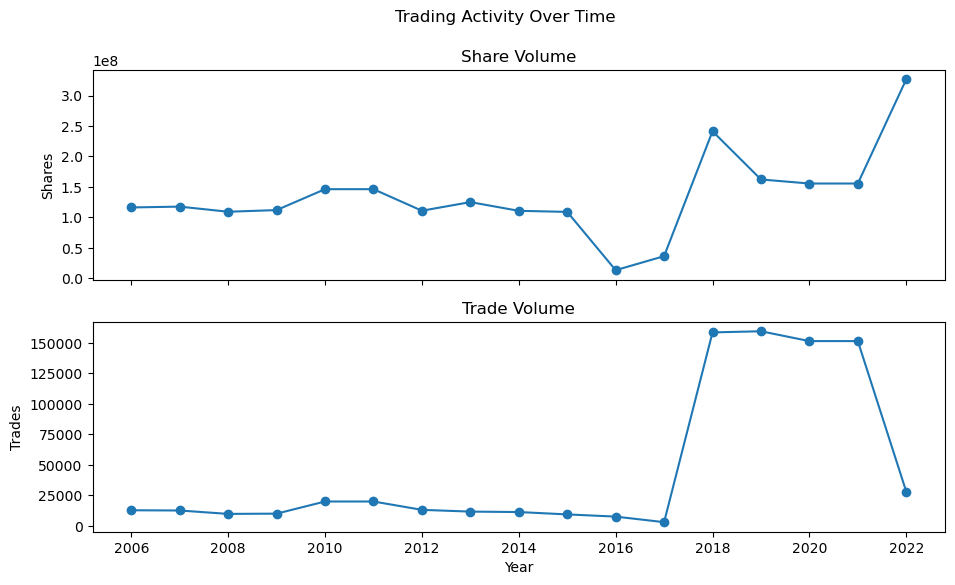

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(11,6), sharex=True)

axes[0].plot(
    company_df2["Year"],
    company_df2["Share_Volume"],
    marker='o'
)
axes[0].set_title("Share Volume")
axes[0].set_ylabel("Shares")

axes[1].plot(
    company_df2["Year"],
    company_df2["Trade_Volume"],
    marker='o'
)
axes[1].set_title("Trade Volume")
axes[1].set_ylabel("Trades")
axes[1].set_xlabel("Year")

fig.suptitle(
    "Trading Activity Over Time"
)

Text(0.5, 0, 'Share Volume')

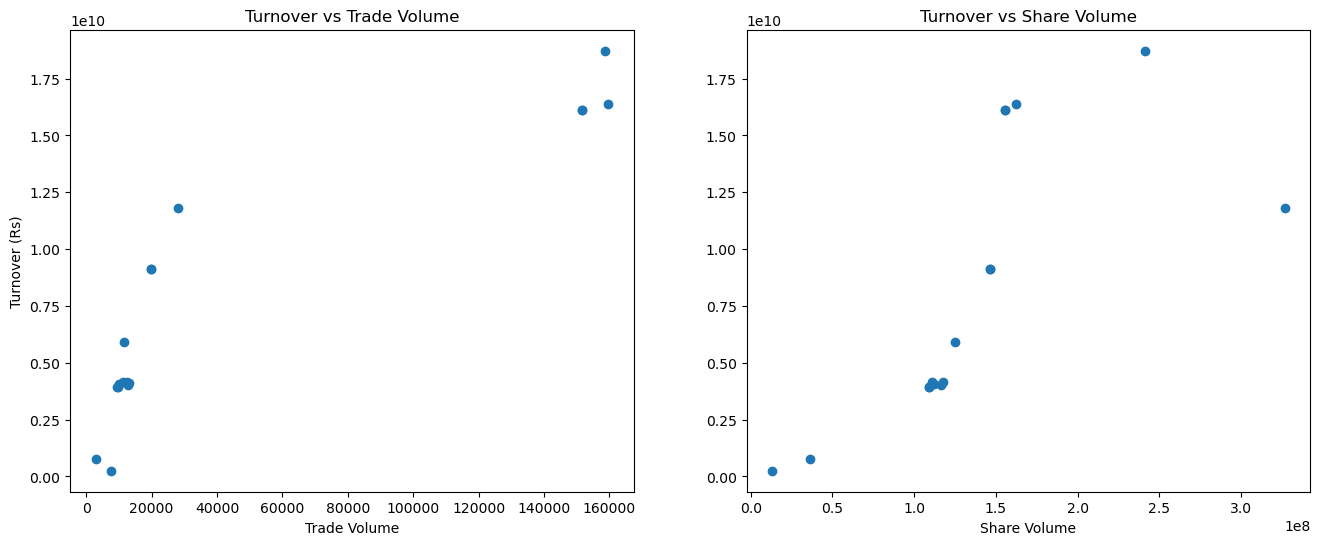

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].scatter(
    company_df2["Trade_Volume"],
    company_df2["Turnover(Rs)"],
)
axes[0].set_title("Turnover vs Trade Volume")
axes[0].set_xlabel("Trade Volume")
axes[0].set_ylabel("Turnover (Rs)")

axes[1].scatter(
    company_df2["Share_Volume"],
    company_df2["Turnover(Rs)"]
)
axes[1].set_title("Turnover vs Share Volume")
axes[1].set_xlabel("Share Volume")

In [66]:
# Kruskal-Wallis
'''
H₀: The distribution of turnover growth rates is the same across all market phases.
H₁: At least one market phase has a significantly different turnover growth distribution.
'''

'\nH₀: The distribution of turnover growth rates is the same across all market phases.\nH₁: At least one market phase has a significantly different turnover growth distribution.\n'

In [67]:
# Remove NaN values (first year has no growth rate)
kw_data2 = company_df2.dropna(subset=["Turnover_Growth_%"])

# Split turnover growth by phase
stable2 = kw_data2.loc[
    kw_data2["Phase"] == "Phase 1: Stable",
    "Turnover_Growth_%"
]

decline2 = kw_data2.loc[
    kw_data2["Phase"] == "Phase 2: Decline",
    "Turnover_Growth_%"
]

expansion2 = kw_data2.loc[
    kw_data2["Phase"] == "Phase 3: Expansion",
    "Turnover_Growth_%"
]

In [68]:
from scipy.stats import kruskal
kw_stat2, p_value2 = kruskal(stable2, decline2, expansion2)

print(f"Kruskal–Wallis H statistic: {kw_stat2:.3f}")
print(f"P-value: {p_value2:.4f}")

Kruskal–Wallis H statistic: 1.960
P-value: 0.3753


Text(0.5, 1.0, 'Price Volatility (High–Low Range)')

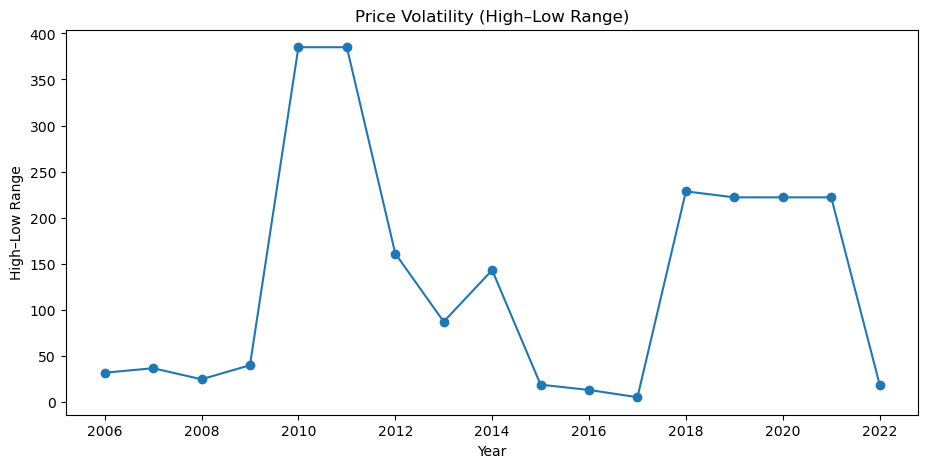

In [69]:
company_df2["High_Low_Range"] = (
    company_df2["High_(Rs)"] - company_df2["Low_(Rs)"]
)

plt.figure(figsize=(11,5))
plt.plot(company_df2["Year"], company_df2["High_Low_Range"], marker='o')
plt.xlabel("Year")
plt.ylabel("High–Low Range")
plt.title("Price Volatility (High–Low Range)")

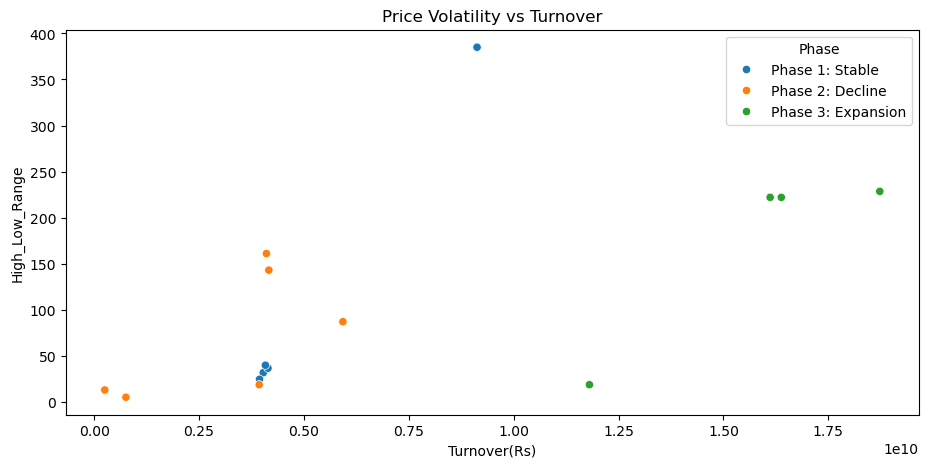

In [70]:
# Volatility vs Turnover
plt.figure(figsize=(11,5))
sns.scatterplot(data=company_df2, x='Turnover(Rs)', y='High_Low_Range', hue='Phase')
plt.title("Price Volatility vs Turnover")
plt.show()

Text(0.5, 1.0, 'Price Volatility vs Share Volume')

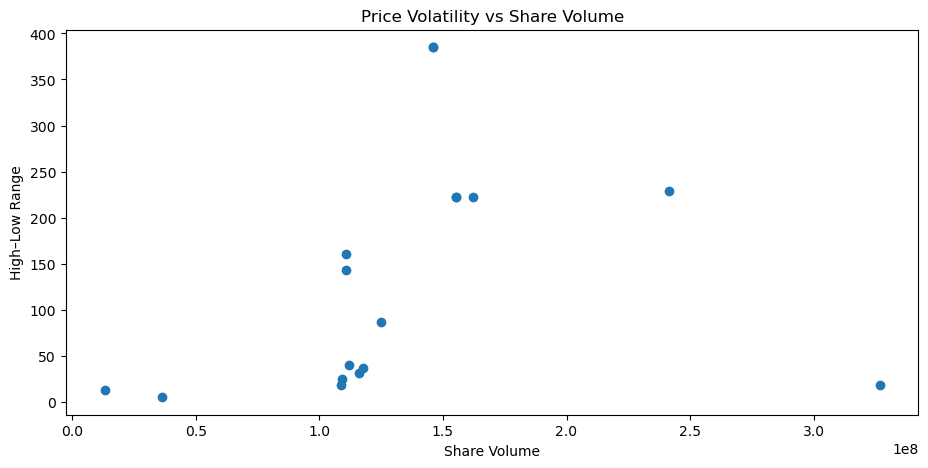

In [71]:
# Volatility vs Share Volume
plt.figure(figsize=(11,5))
plt.scatter(company_df2["Share_Volume"], company_df2["High_Low_Range"])
plt.xlabel("Share Volume")
plt.ylabel("High–Low Range")
plt.title("Price Volatility vs Share Volume")

Text(0.5, 1.0, 'Price Volatility vs Trade Volume')

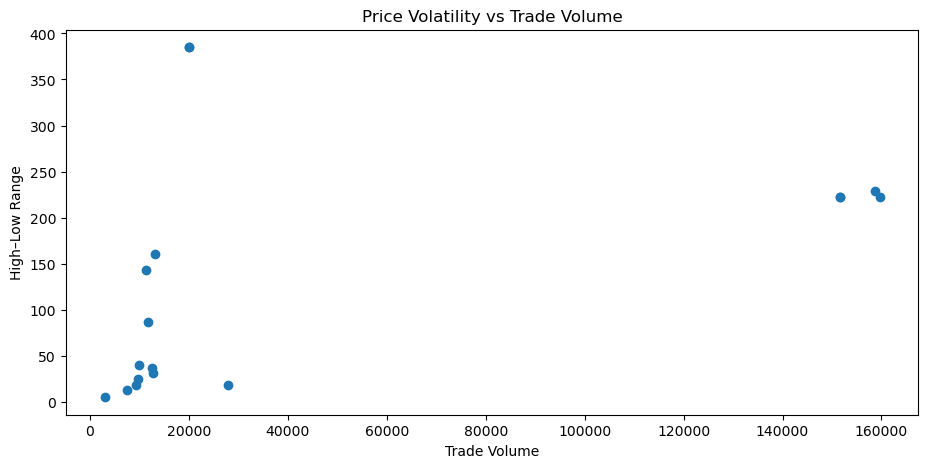

In [72]:
# Volatility vs Trade Volume
plt.figure(figsize=(11,5))
plt.scatter(company_df2["Trade_Volume"], company_df2["High_Low_Range"])
plt.xlabel("Trade Volume")
plt.ylabel("High–Low Range")
plt.title("Price Volatility vs Trade Volume")

In [73]:
from scipy.stats import pearsonr, spearmanr
variables = ["Turnover(Rs)", "Share_Volume", "Trade_Volume"]
for var in variables:
    pearson_corr2, _ = pearsonr(company_df2[var], company_df2["High_Low_Range"])
    spearman_corr2, _ = spearmanr(company_df2[var], company_df2["High_Low_Range"])
    
    print(f"{var}:")
    print(f"  Pearson correlation  = {pearson_corr2:.3f}")
    print(f"  Spearman correlation = {spearman_corr2:.3f}\n")


Turnover(Rs):
  Pearson correlation  = 0.597
  Spearman correlation = 0.772

Share_Volume:
  Pearson correlation  = 0.268
  Spearman correlation = 0.629

Trade_Volume:
  Pearson correlation  = 0.448
  Spearman correlation = 0.750



In [74]:
#Ordinal least squares regression model

company_df2["Phase2"] = ((company_df2["Year"] > 2010) & (company_df2["Year"] <= 2017)).astype(int)
company_df2["Phase3"] = (company_df2["Year"] > 2017).astype(int)

X = sm.add_constant(company_df2[["Phase2", "Phase3"]])
y = np.log(company_df2["Turnover(Rs)"])

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Turnover(Rs)   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     6.486
Date:                Mon, 02 Feb 2026   Prob (F-statistic):             0.0102
Time:                        18:28:34   Log-Likelihood:                -19.972
No. Observations:                  17   AIC:                             45.94
Df Residuals:                      14   BIC:                             48.44
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.2842      0.386     57.722      0.0

C:\Users\META\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [75]:
#LOLC HOLDINGS PLC

In [76]:
company_symbol = "LOLC.N0000"

company_df3 = (
    merged_df[merged_df["Symbol"] == company_symbol]
    .sort_values("Year")
    .reset_index(drop=True)
)

company_df3

,Symbol,Company_Name,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year,GICS Industry Group
0,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,85.5,632.50,226287,165156325,7.041708e+10,2006,Diversified Financials
1,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,81.0,649.25,230783,168643025,7.095516e+10,2007,Diversified Financials
2,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,58.0,610.00,226526,165297425,7.044131e+10,2008,Diversified Financials
3,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,61.5,649.50,227449,166274525,7.056727e+10,2009,Diversified Financials
4,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,74.5,622.65,241791,188935825,7.322269e+10,2010,Diversified Financials
5,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,74.5,622.65,241791,188935825,7.322269e+10,2011,Diversified Financials
6,LOLC.N0000,L O L C HOLDINGS PLC,118.0,1210.0,26.5,607.90,235824,188610752,7.154487e+10,2012,Diversified Financials
7,LOLC.N0000,L O L C HOLDINGS PLC,94.9,1210.0,49.5,617.30,233927,196738503,7.254524e+10,2013,Diversified Financials
8,LOLC.N0000,L O L C HOLDINGS PLC,104.5,1210.0,70.2,625.00,228164,168634013,7.068854e+10,2014,Diversified Financials
9,LOLC.N0000,L O L C HOLDINGS PLC,136.0,1210.0,136.0,1162.00,225123,164120325,7.030986e+10,2015,Diversified Financials


In [77]:
company_df3["Volatility"] = company_df3["High_(Rs)"] - company_df3["Low_(Rs)"]

In [78]:
company_df3[["Open_(Rs)", "High_(Rs)", "Low_(Rs)", "Close_(Rs)", "Trade_Volume", "Share_Volume", "Turnover(Rs)", "Volatility"]].describe()

,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Volatility
count,17.000000,17.000000,17.000000,17.000000,17.000000,1.700000e+01,1.700000e+01,17.000000
mean,299.482353,1147.382353,95.570588,557.414706,201837.941176,1.494856e+08,5.952463e+10,1051.811765
std,372.427988,404.913013,60.669481,298.764865,147245.223809,1.141729e+08,4.820011e+10,386.131896
min,72.500000,94.500000,26.500000,72.500000,3163.000000,1.079120e+07,8.951235e+08,30.400000
25%,118.000000,1210.000000,61.500000,398.000000,106838.000000,3.766430e+07,1.887274e+10,1124.500000
50%,118.000000,1210.000000,74.500000,617.300000,226526.000000,1.662745e+08,7.044131e+10,1139.800000
75%,136.000000,1210.000000,86.000000,632.500000,233927.000000,1.886108e+08,7.154487e+10,1183.500000
max,1174.500000,1489.000000,240.000000,1162.000000,675369.000000,4.923610e+08,2.109296e+11,1406.600000


Text(2021, 50000000000.0, 'Expansion \nPhase')

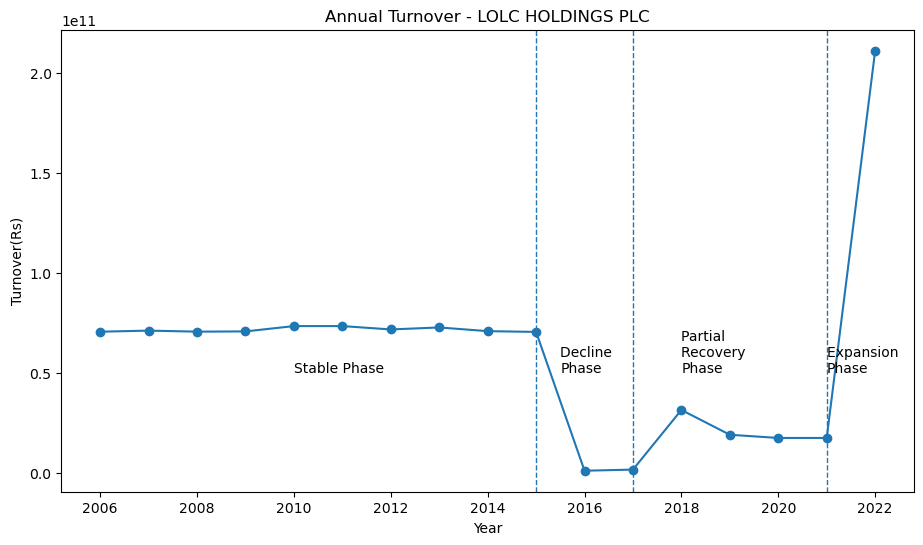

In [79]:
plt.figure(figsize=(11,6))
plt.plot(company_df3["Year"], company_df3["Turnover(Rs)"], marker='o')
plt.xlabel("Year")
plt.ylabel("Turnover(Rs)")
plt.title("Annual Turnover - LOLC HOLDINGS PLC")

# Phase boundaries
plt.axvline(2015, linestyle='--', linewidth=1)
plt.axvline(2017, linestyle='--', linewidth=1)
plt.axvline(2021, linestyle='--', linewidth=1)

# Phase annotations
plt.text(2010, 5e10, "Stable Phase", fontsize=10)
plt.text(2015.5, 5e10, "Decline \nPhase", fontsize=10)
plt.text(2018, 5e10, "Partial \nRecovery \nPhase", fontsize=10)
plt.text(2021, 5e10, "Expansion \nPhase", fontsize=10)

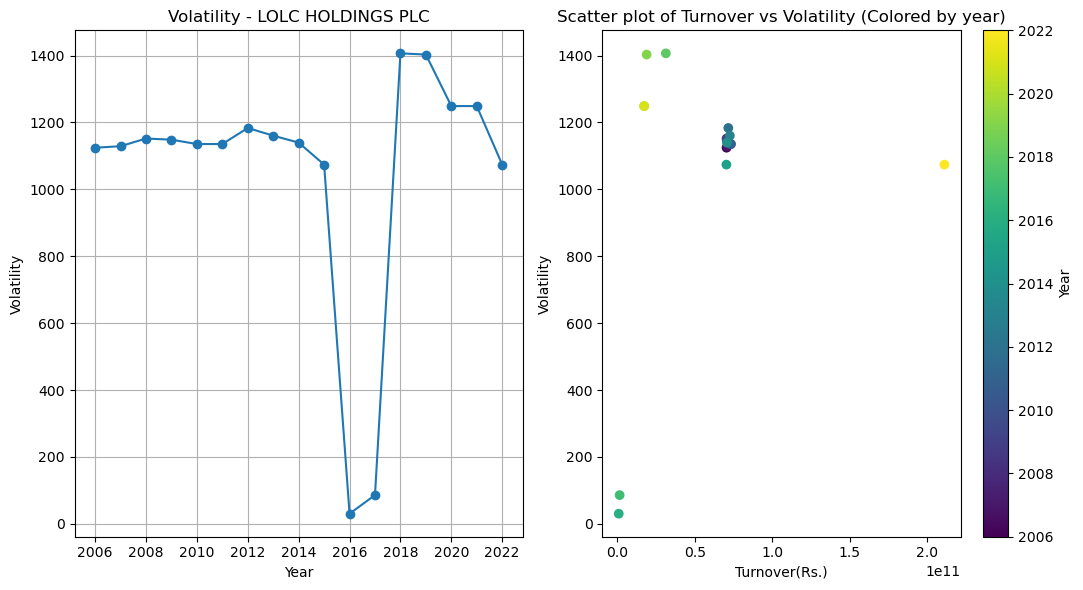

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(11,6))

axes[0].plot(
    company_df3["Year"],
    company_df3["Volatility"],
    marker='o'
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Volatility")
axes[0].grid()
axes[0].set_title("Volatility - LOLC HOLDINGS PLC")

sc=axes[1].scatter(
    company_df3["Turnover(Rs)"],
    company_df3["Volatility"],
    c = company_df3["Year"],
    cmap = "viridis",
    marker='o'
)
plt.colorbar(sc, label="Year")
axes[1].set_xlabel("Turnover(Rs.)")
axes[1].set_ylabel("Volatility")
axes[1].set_title("Scatter plot of Turnover vs Volatility (Colored by year)")


plt.tight_layout()

In [81]:
# Trend Hypothesis
'''H₀: There is no statistically significant trend in annual turnover over the period 2006–2022.
 H₁: There is a statistically significant trend in annual turnover over the period 2006–2022.'''
# Relationship Hypothesis
'''H₀: There is no statistically significant relationship between annual turnover and key trading indicators.
H₁: There exists a statistically significant relationship between annual turnover and key trading indicators.'''

'H₀: There is no statistically significant relationship between annual turnover and key trading indicators.\nH₁: There exists a statistically significant relationship between annual turnover and key trading indicators.'

Data used (rows): 17


,Year,Trade_Volume,Turnover(Rs),Volatility
0,2006,226287,7.041708e+10,1124.5
1,2007,230783,7.095516e+10,1129.0
2,2008,226526,7.044131e+10,1152.0
3,2009,227449,7.056727e+10,1148.5
4,2010,241791,7.322269e+10,1135.5



Trend test (raw): Turnover(Rs)
  Slope (per year): -8.71591e+08
  p-value: 0.7274
  R^2: 0.008338

Trend test (raw): Trade_Volume
  Slope (per year): -790.826
  p-value: 0.9177
  R^2: 0.0007356

Trend test (raw): Volatility
  Slope (per year): -5.30956
  p-value: 0.7912
  R^2: 0.004822

Trend test (log1p): Turnover(Rs)
  Slope (per year): -0.0982246
  p-value: 0.1762
  R^2: 0.1184

Trend test (log1p): Trade_Volume
  Slope (per year): -0.0670207
  p-value: 0.3223
  R^2: 0.06527

Relationship: Turnover vs Trade Volume
  Spearman rho = 0.9951, p-value = 1.754e-16
  Pearson r    = 0.9935, p-value = 1.462e-15

Relationship: Turnover vs Volatility
  Spearman rho = -0.0615, p-value = 0.8147
  Pearson r    = 0.2979, p-value = 0.2455

Relationship (log1p Pearson): log(1+Turnover) vs log(1+Trade Volume)
  Pearson r = 0.9869, p-value = 2.688e-13


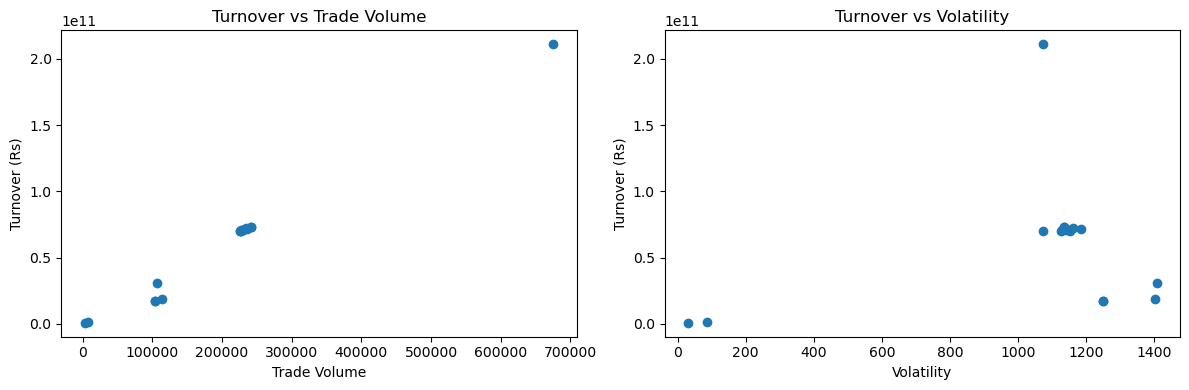

In [82]:
# 0) Choose dataframe
df = company_df3.copy()

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Keep only needed columns
cols = ["Year", "Trade_Volume", "Turnover(Rs)", "Volatility"]
df = df[cols].dropna()

print("Data used (rows):", len(df))
display(df.head())

# TREND TESTS over time (Year → Indicator)
def linear_trend_test(data, y_col):
    """
    OLS regression: y ~ Year
    Returns slope, p-value, R^2.
    """
    X = sm.add_constant(data["Year"]) 
    y = data[y_col]
    model = sm.OLS(y, X).fit()
    slope = model.params["Year"]
    pval = model.pvalues["Year"]
    r2 = model.rsquared
    return slope, pval, r2, model

# Trend tests on raw scale
for var in ["Turnover(Rs)", "Trade_Volume", "Volatility"]:
    slope, pval, r2, model = linear_trend_test(df, var)
    print(f"\nTrend test (raw): {var}")
    print(f"  Slope (per year): {slope:.6g}")
    print(f"  p-value: {pval:.4g}")
    print(f"  R^2: {r2:.4g}")

# Trend tests on log scale
df_log = df.copy()
for var in ["Turnover(Rs)", "Trade_Volume"]:
    df_log[var] = np.log1p(df_log[var])

for var in ["Turnover(Rs)", "Trade_Volume"]:
    slope, pval, r2, model = linear_trend_test(df_log, var)
    print(f"\nTrend test (log1p): {var}")
    print(f"  Slope (per year): {slope:.6g}")
    print(f"  p-value: {pval:.4g}")
    print(f"  R^2: {r2:.4g}")

# RELATIONSHIP TESTS between variables

def corr_tests(data, x, y):
    """
    Spearman (robust for skew/outliers) and Pearson on raw scale.
    Also Pearson on log1p scale for heavy-tailed variables.
    """
    # Spearman correlation
    rho, p_s = spearmanr(data[x], data[y], nan_policy="omit")

    # Pearson correlation (raw)
    r, p_p = pearsonr(data[x], data[y])

    return rho, p_s, r, p_p

# 1) Turnover vs Trade Volume
rho, p_s, r, p_p = corr_tests(df, "Trade_Volume", "Turnover(Rs)")
print("\nRelationship: Turnover vs Trade Volume")
print(f"  Spearman rho = {rho:.4f}, p-value = {p_s:.4g}")
print(f"  Pearson r    = {r:.4f}, p-value = {p_p:.4g}")

# 2) Turnover vs Volatility
rho, p_s, r, p_p = corr_tests(df, "Volatility", "Turnover(Rs)")
print("\nRelationship: Turnover vs Volatility")
print(f"  Spearman rho = {rho:.4f}, p-value = {p_s:.4g}")
print(f"  Pearson r    = {r:.4f}, p-value = {p_p:.4g}")

# Pearson after log transform 
df_log_corr = df.copy()
df_log_corr["Turnover_log"] = np.log1p(df_log_corr["Turnover(Rs)"])
df_log_corr["Volume_log"] = np.log1p(df_log_corr["Trade_Volume"])

r_lv, p_lv = pearsonr(df_log_corr["Volume_log"], df_log_corr["Turnover_log"])
print("\nRelationship (log1p Pearson): log(1+Turnover) vs log(1+Trade Volume)")
print(f"  Pearson r = {r_lv:.4f}, p-value = {p_lv:.4g}")

# visuals

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["Trade_Volume"], df["Turnover(Rs)"])
axes[0].set_title("Turnover vs Trade Volume")
axes[0].set_xlabel("Trade Volume")
axes[0].set_ylabel("Turnover (Rs)")

axes[1].scatter(df["Volatility"], df["Turnover(Rs)"])
axes[1].set_title("Turnover vs Volatility")
axes[1].set_xlabel("Volatility")
axes[1].set_ylabel("Turnover (Rs)")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Year-to-Year Turnover Growth')

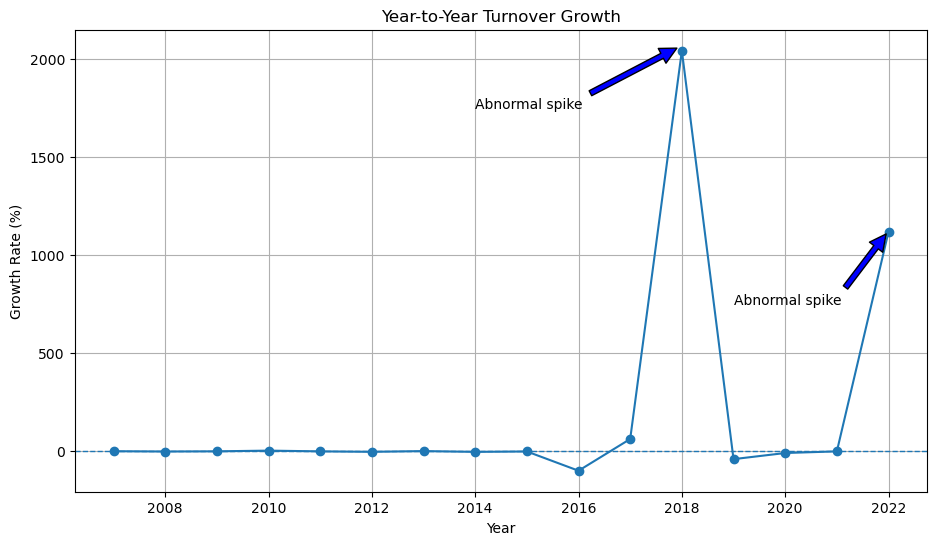

In [83]:
company_df3["Turnover_Growth_%"] = company_df3["Turnover(Rs)"].pct_change() * 100


plt.figure(figsize=(11,6))
plt.plot(company_df3["Year"], company_df3["Turnover_Growth_%"], marker='o')
plt.annotate('Abnormal spike', xy=(2018,2070), xytext=(2014,1750), arrowprops=dict(facecolor='b', shrink=0.05))
plt.annotate('Abnormal spike', xy=(2022,1125), xytext=(2019,750), arrowprops=dict(facecolor='b', shrink=0.05))
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Year")
plt.grid()
plt.ylabel("Growth Rate (%)")
plt.title("Year-to-Year Turnover Growth")

In [84]:
def growth_category(x):
    if pd.isna(x):
        return "NA"
    elif abs(x) > 100:
        return "Extreme spike"
    elif abs(x) > 30:
        return "Moderate change"
    else:
        return "Normal fluctuation"

company_df3["Growth_Category"] = company_df3["Turnover_Growth_%"].apply(growth_category)

company_df3[["Year", "Turnover_Growth_%", "Growth_Category"]]


,Year,Turnover_Growth_%,Growth_Category
0,2006,NaN,NA
1,2007,0.764125,Normal fluctuation
2,2008,-0.724183,Normal fluctuation
3,2009,0.178819,Normal fluctuation
4,2010,3.762961,Normal fluctuation
5,2011,0.000000,Normal fluctuation
6,2012,-2.291395,Normal fluctuation
7,2013,1.398232,Normal fluctuation
8,2014,-2.559370,Normal fluctuation
9,2015,-0.535692,Normal fluctuation


In [85]:
#Create period labels

from scipy.stats import mannwhitneyu

df3 = company_df3.copy()

# Create period variable
df3["Period"] = df["Year"].apply(
    lambda x: "2006–2014 (Stable)" if x <= 2014 else "2015–2022 (Turbulent)"
)

df3[["Year", "Period"]].head(17)


,Year,Period
0,2006,2006–2014 (Stable)
1,2007,2006–2014 (Stable)
2,2008,2006–2014 (Stable)
3,2009,2006–2014 (Stable)
4,2010,2006–2014 (Stable)
5,2011,2006–2014 (Stable)
6,2012,2006–2014 (Stable)
7,2013,2006–2014 (Stable)
8,2014,2006–2014 (Stable)
9,2015,2015–2022 (Turbulent)


In [86]:
# Period Comparison Analysis using Mann-Whitney U test
'''H₀: The distribution (median) of the trading indicator(Turnover, Trade volume, Share volume, Volatility) is the same in the two periods 2006-2014 and 2015-2022
H₁: The distribution (median) of the trading indicator(Turnover, Trade volume, Share volume, Volatility) differs between the two periods 2006-2014 and 2015-2022'''

'H₀: The distribution (median) of the trading indicator(Turnover, Trade volume, Share volume, Volatility) is the same in the two periods 2006-2014 and 2015-2022\nH₁: The distribution (median) of the trading indicator(Turnover, Trade volume, Share volume, Volatility) differs between the two periods 2006-2014 and 2015-2022'

In [87]:
#Function to compare periods

def period_comparison(df3, variable):
    group1 = df3[df3["Period"] == "2006–2014 (Stable)"][variable]
    group2 = df3[df3["Period"] == "2015–2022 (Turbulent)"][variable]

    # Mean values (descriptive)
    mean1 = group1.mean()
    mean2 = group2.mean()

    # Mann–Whitney U test
    u_stat, p_value = mannwhitneyu(group1, group2, alternative="two-sided")

    return mean1, mean2, u_stat, p_value


In [88]:
#Run the test for key indicators

variables = [
    "Turnover(Rs)",
    "Trade_Volume",
    "Share_Volume",
    "Volatility"
]

for var in variables:
    mean1, mean2, u_stat, p_val = period_comparison(df3, var)
    print(f"\nVariable: {var}")
    print(f" Mean (2006–2014): {mean1:.3e}")
    print(f" Mean (2015–2022): {mean2:.3e}")
    print(f" Mann–Whitney U: {u_stat:.2f}")
    print(f" p-value: {p_val:.4f}")



Variable: Turnover(Rs)
 Mean (2006–2014): 7.151e+10
 Mean (2015–2022): 4.604e+10
 Mann–Whitney U: 63.00
 p-value: 0.0107

Variable: Trade_Volume
 Mean (2006–2014): 2.325e+05
 Mean (2015–2022): 1.673e+05
 Mann–Whitney U: 63.00
 p-value: 0.0107

Variable: Share_Volume
 Mean (2006–2014): 1.775e+08
 Mean (2015–2022): 1.180e+08
 Mann–Whitney U: 58.00
 p-value: 0.0383

Variable: Volatility
 Mean (2006–2014): 1.145e+03
 Mean (2015–2022): 9.465e+02
 Mann–Whitney U: 36.00
 p-value: 1.0000


In [89]:
#EXPOLANKA HOLDINGS PLC

In [90]:
company_symbol = "EXPO.N0000"
company_df4 = (
    merged_df[merged_df["Symbol"] == company_symbol]
    .sort_values("Year")
    .reset_index(drop=True)
)

company_df4

,Symbol,Company_Name,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year,GICS Industry Group
0,EXPO.N0000,EXPOLANKA HOLDINGS PLC,29.30,390.0,29.2,375.250,659361,1829108975,1.855597e+11,2006,Transportation
1,EXPO.N0000,EXPOLANKA HOLDINGS PLC,29.30,390.0,29.2,375.250,659361,1829108975,1.855597e+11,2007,Transportation
2,EXPO.N0000,EXPOLANKA HOLDINGS PLC,29.30,390.0,29.2,375.250,659361,1829108975,1.855597e+11,2008,Transportation
3,EXPO.N0000,EXPOLANKA HOLDINGS PLC,29.30,390.0,29.2,375.250,659361,1829108975,1.855597e+11,2009,Transportation
4,EXPO.N0000,EXPOLANKA HOLDINGS PLC,14.65,390.0,8.3,192.125,684270,2054479875,1.885014e+11,2010,Transportation
5,EXPO.N0000,EXPOLANKA HOLDINGS PLC,14.65,390.0,8.3,192.125,684270,2054479875,1.885014e+11,2011,Transportation
6,EXPO.N0000,EXPOLANKA HOLDINGS PLC,14.65,390.0,5.5,191.125,672481,1955819488,1.864469e+11,2012,Transportation
7,EXPO.N0000,EXPOLANKA HOLDINGS PLC,29.30,390.0,29.2,375.250,659361,1829108975,1.855597e+11,2013,Transportation
8,EXPO.N0000,EXPOLANKA HOLDINGS PLC,18.40,390.0,7.5,191.925,677601,2712939561,1.947149e+11,2014,Transportation
9,EXPO.N0000,EXPOLANKA HOLDINGS PLC,29.30,390.0,29.2,375.250,659361,1829108975,1.855597e+11,2015,Transportation


In [91]:
company_df4.describe()

,Open_(Rs),High_(Rs),Low_(Rs),Close_(Rs),Trade_Volume,Share_Volume,Turnover(Rs),Year
count,17.000000,17.000000,17.000000,17.000000,1.700000e+01,1.700000e+01,1.700000e+01,17.000000
mean,83.385294,348.547059,25.458824,232.761765,6.146304e+05,1.671127e+09,1.726120e+11,2014.000000
std,123.995957,128.469783,26.769807,135.967471,4.142041e+05,1.227824e+09,1.163108e+11,5.049752
min,6.300000,7.100000,3.800000,5.300000,4.031000e+03,2.597137e+08,1.597226e+09,2006.000000
25%,14.650000,390.000000,5.900000,182.250000,4.502060e+05,6.491184e+08,1.253677e+11,2010.000000
50%,29.300000,390.000000,29.200000,192.125000,6.593610e+05,1.829109e+09,1.855597e+11,2014.000000
75%,29.300000,390.000000,29.200000,375.250000,6.724810e+05,1.955819e+09,1.864469e+11,2018.000000
max,377.000000,405.000000,90.000000,375.250000,1.978083e+06,5.487327e+09,5.566790e+11,2022.000000


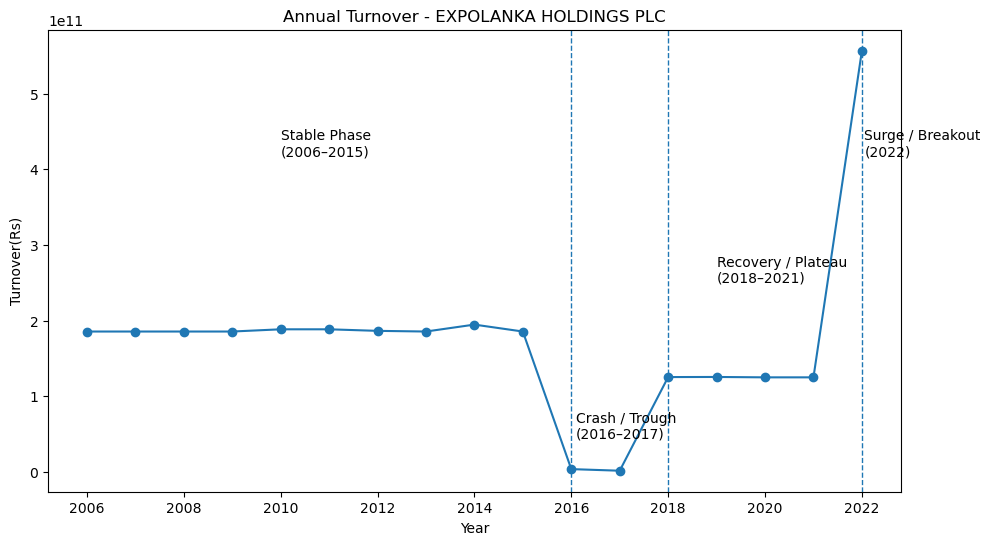

In [92]:
#Annual Turnover and closing price trends

plt.figure(figsize=(11,6))
plt.plot(company_df4["Year"], company_df4["Turnover(Rs)"], marker="o")
plt.xlabel("Year")
plt.ylabel("Turnover(Rs)")
plt.title("Annual Turnover - EXPOLANKA HOLDINGS PLC")

#Phase boundaries

plt.axvline(2016, linestyle="--", linewidth=1)
plt.axvline(2018, linestyle="--", linewidth=1)
plt.axvline(2022, linestyle="--", linewidth=1)

#Phase annotations
y_max = company_df4["Turnover(Rs)"].max()
y_top = y_max * 0.75          # near top for most labels
y_mid = y_max * 0.45
y_low = y_max * 0.08          # near bottom for the crash phase label

plt.text(2010, y_top, "Stable Phase\n(2006–2015)", fontsize=10)
plt.text(2016.1, y_low, "Crash / Trough\n(2016–2017)", fontsize=10)
plt.text(2019.0, y_mid, "Recovery / Plateau\n(2018–2021)", fontsize=10)
plt.text(2022.05, y_top, "Surge / Breakout\n(2022)", fontsize=10)

plt.show()

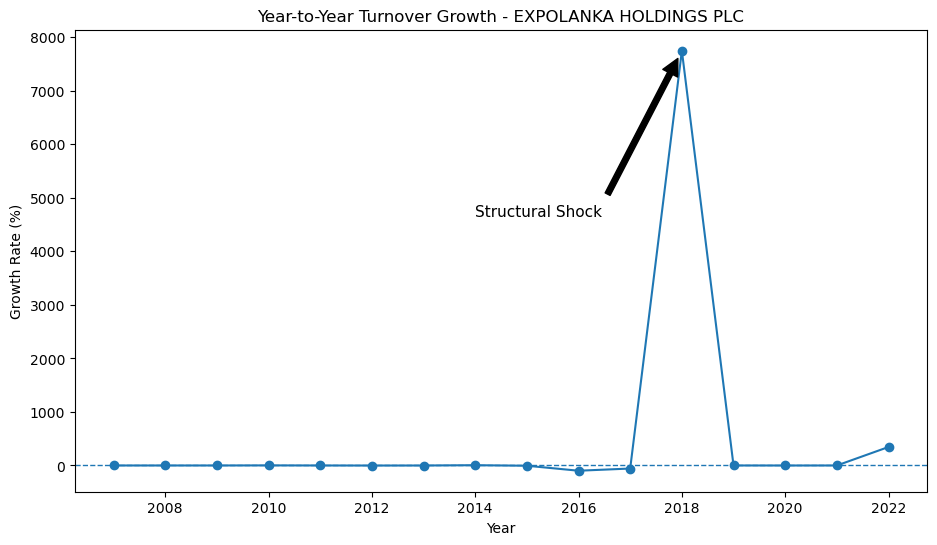

In [93]:
# Year-to-Year Turnover Growth (%)


company_df4["Turnover_Growth_%"] = (
    company_df4["Turnover(Rs)"].pct_change() * 100
)

plt.figure(figsize=(11,6))
plt.plot(company_df4["Year"],company_df4["Turnover_Growth_%"], marker="o")

shock_year = 2018
shock_value = company_df4.loc[
    company_df4["Year"] == shock_year, "Turnover_Growth_%"
].values[0]

plt.annotate(
    "Structural Shock",
    xy=(shock_year, shock_value),
    xytext=(2014, shock_value * 0.6),
    arrowprops=dict(facecolor="black", shrink=0.05),
    fontsize=11
)

# Reference line at zero growth
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("Year-to-Year Turnover Growth - EXPOLANKA HOLDINGS PLC")

plt.show()

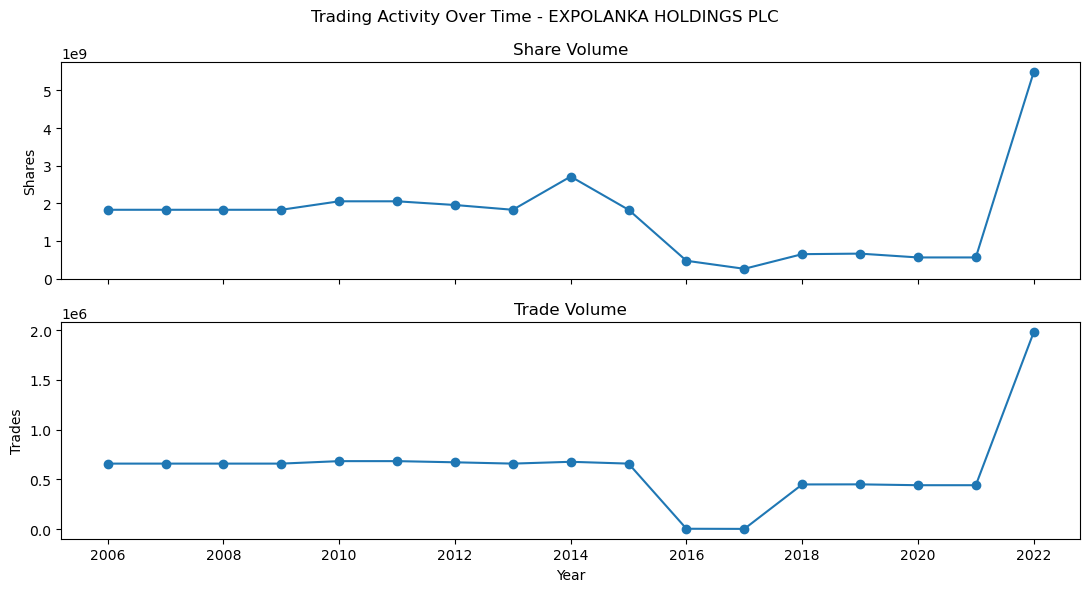

In [94]:
#Trading activity over time

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(company_df4["Year"], company_df4["Share_Volume"], marker="o")
axes[0].set_title("Share Volume")
axes[0].set_ylabel("Shares")

axes[1].plot(company_df4["Year"], company_df4["Trade_Volume"], marker="o")
axes[1].set_title("Trade Volume")
axes[1].set_ylabel("Trades")
axes[1].set_xlabel("Year")

fig.suptitle("Trading Activity Over Time - EXPOLANKA HOLDINGS PLC")
plt.tight_layout()
plt.show()

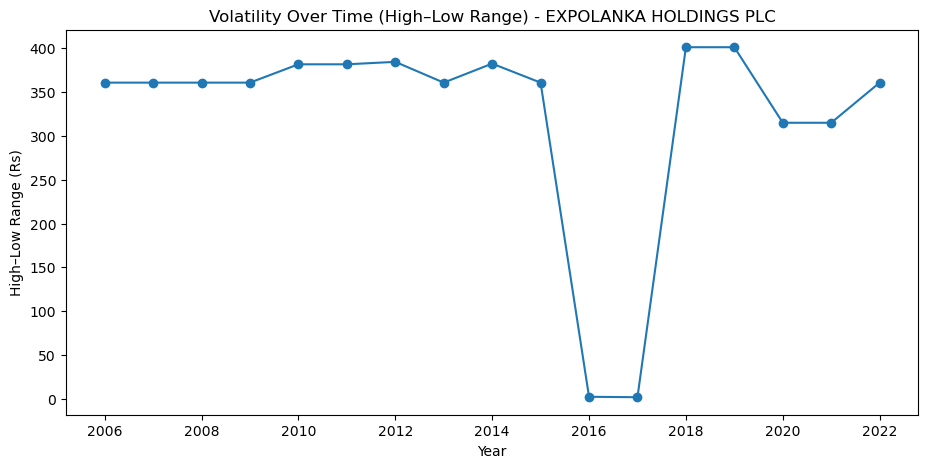

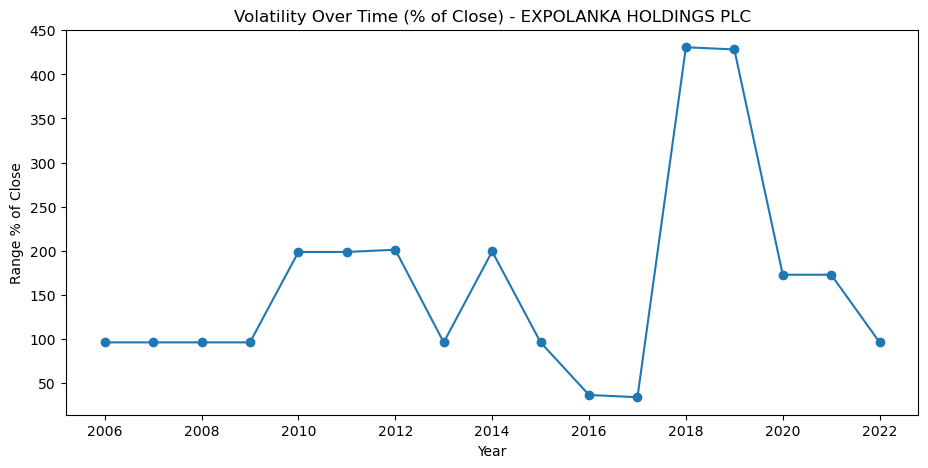

In [95]:
#Volatility Analysis
company_df4["High_Low_Range"] = (
    company_df4["High_(Rs)"] - company_df4["Low_(Rs)"]
)

company_df4["Range_pct_of_Close"] = (
    company_df4["High_Low_Range"] / company_df4["Close_(Rs)"]
) * 100

plt.figure(figsize=(11, 5))
plt.plot(company_df4["Year"], company_df4["High_Low_Range"], marker="o")
plt.title("Volatility Over Time (High–Low Range) - EXPOLANKA HOLDINGS PLC")
plt.xlabel("Year")
plt.ylabel("High–Low Range (Rs)")
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(company_df4["Year"], company_df4["Range_pct_of_Close"], marker="o")
plt.title("Volatility Over Time (% of Close) - EXPOLANKA HOLDINGS PLC")
plt.xlabel("Year")
plt.ylabel("Range % of Close")
plt.show()


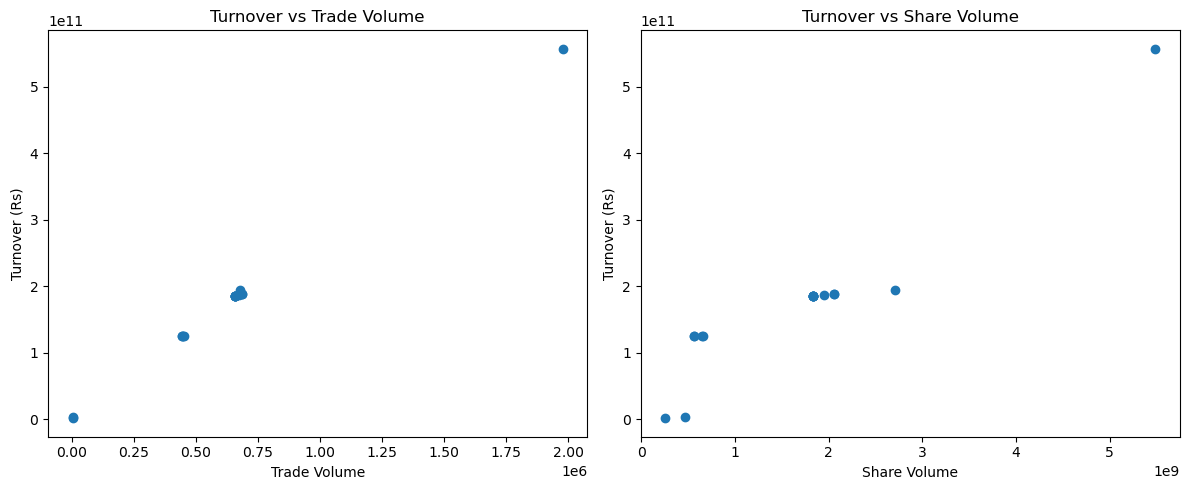

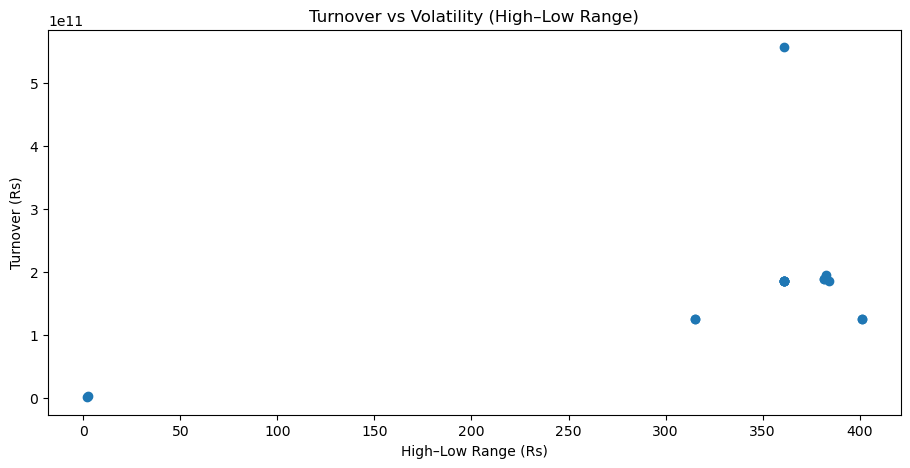

In [96]:
#Relationship Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(company_df4["Trade_Volume"], company_df4["Turnover(Rs)"])
axes[0].set_title("Turnover vs Trade Volume")
axes[0].set_xlabel("Trade Volume")
axes[0].set_ylabel("Turnover (Rs)")

axes[1].scatter(company_df4["Share_Volume"], company_df4["Turnover(Rs)"])
axes[1].set_title("Turnover vs Share Volume")
axes[1].set_xlabel("Share Volume")
axes[1].set_ylabel("Turnover (Rs)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.scatter(company_df4["High_Low_Range"], company_df4["Turnover(Rs)"])
plt.title("Turnover vs Volatility (High–Low Range)")
plt.xlabel("High–Low Range (Rs)")
plt.ylabel("Turnover (Rs)")
plt.show()


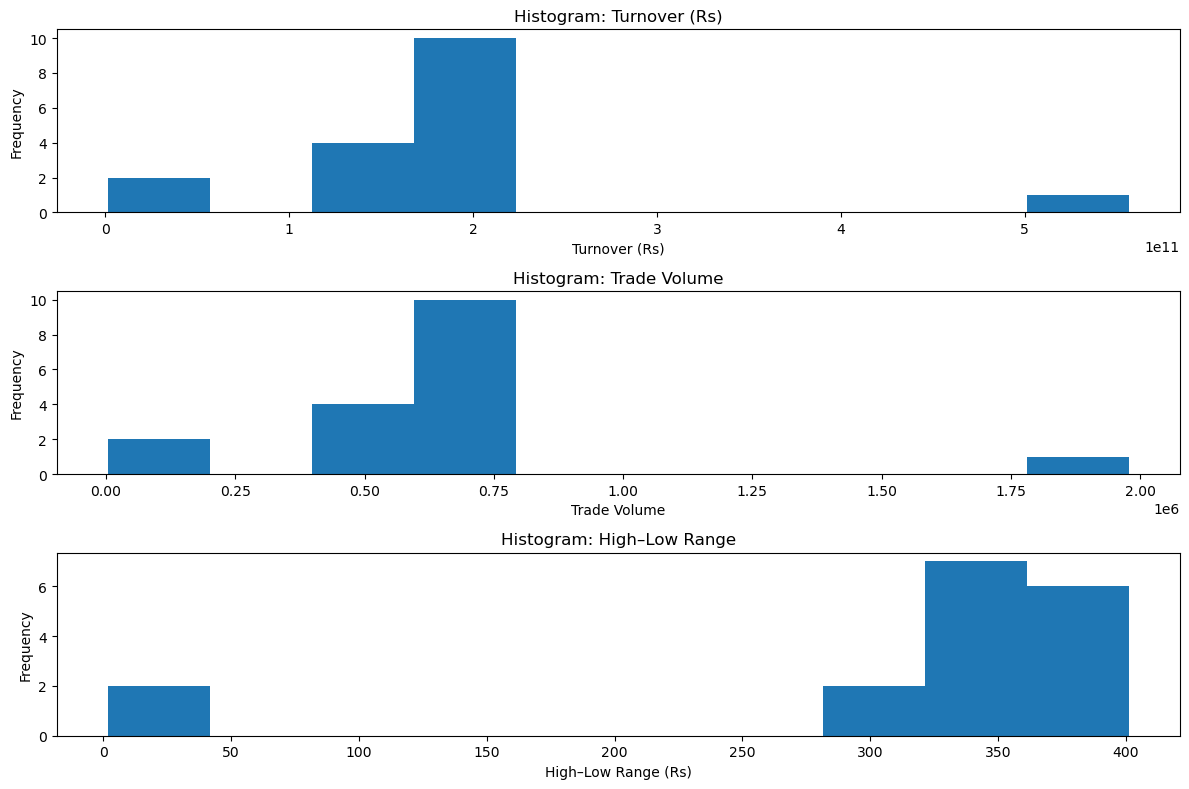

In [97]:
#Distribution Analysis
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Histogram: Turnover
axes[0].hist(company_df4["Turnover(Rs)"].dropna(), bins=10)
axes[0].set_title("Histogram: Turnover (Rs)")
axes[0].set_xlabel("Turnover (Rs)")
axes[0].set_ylabel("Frequency")

# Histogram: Trade Volume
axes[1].hist(company_df4["Trade_Volume"].dropna(), bins=10)
axes[1].set_title("Histogram: Trade Volume")
axes[1].set_xlabel("Trade Volume")
axes[1].set_ylabel("Frequency")

# Histogram: High–Low Range
axes[2].hist(company_df4["High_Low_Range"].dropna(), bins=10)
axes[2].set_title("Histogram: High–Low Range")
axes[2].set_xlabel("High–Low Range (Rs)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\META\AppData\Local\Temp\ipykernel_17812\964984745.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


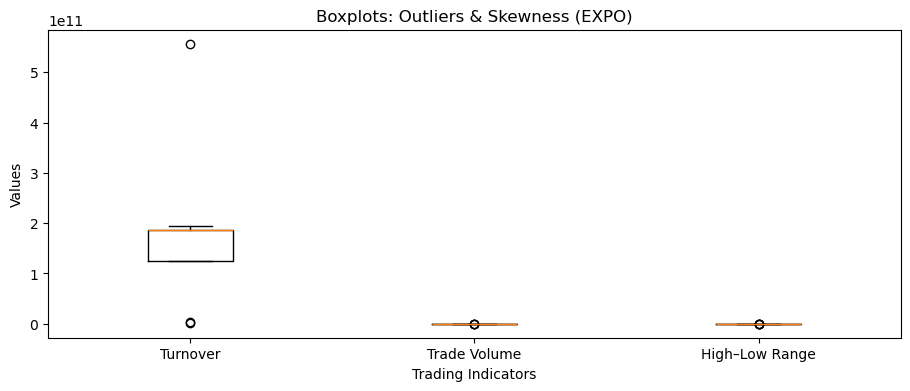

In [98]:
plt.figure(figsize=(11, 4))

plt.boxplot(
    [
        company_df4["Turnover(Rs)"].dropna(),
        company_df4["Trade_Volume"].dropna(),
        company_df4["High_Low_Range"].dropna()
    ],
    labels=["Turnover", "Trade Volume", "High–Low Range"]
)

plt.title("Boxplots: Outliers & Skewness (EXPO)")
plt.xlabel("Trading Indicators")
plt.ylabel("Values")

plt.show()

In [99]:
key_cols = ["Turnover(Rs)", "Trade_Volume", "Share_Volume", "High_Low_Range", "Range_pct_of_Close"]

display(company_df4[key_cols].corr(method="pearson"))
display(company_df4[key_cols].corr(method="spearman"))

# Example correlation test (Turnover vs Trade Volume)
x = company_df4["Trade_Volume"].dropna()
y = company_df4["Turnover(Rs)"].dropna()
r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)

print("Pearson:  r =", r_p, "p =", p_p)
print("Spearman: r =", r_s, "p =", p_s)

,Turnover(Rs),Trade_Volume,Share_Volume,High_Low_Range,Range_pct_of_Close
Turnover(Rs),1.000000,0.999854,0.946245,0.540964,-0.051689
Trade_Volume,0.999854,1.000000,0.944701,0.546276,-0.045382
Share_Volume,0.946245,0.944701,1.000000,0.413833,-0.208832
High_Low_Range,0.540964,0.546276,0.413833,1.000000,0.505706
Range_pct_of_Close,-0.051689,-0.045382,-0.208832,0.505706,1.000000


,Turnover(Rs),Trade_Volume,Share_Volume,High_Low_Range,Range_pct_of_Close
Turnover(Rs),1.000000,0.992298,1.000000,0.540420,0.281093
Trade_Volume,0.992298,1.000000,0.992298,0.532607,0.273285
Share_Volume,1.000000,0.992298,1.000000,0.540420,0.281093
High_Low_Range,0.540420,0.532607,0.540420,1.000000,0.833003
Range_pct_of_Close,0.281093,0.273285,0.281093,0.833003,1.000000


Pearson:  r = 0.999854209375401 p = 6.1969343077093815e-28
Spearman: r = 0.9922978177150192 p = 5.062704123197318e-15


In [100]:
#Advanced Analysis
#Hypothesis testing

'''Null Hypothesis (H₀) -:There is no statistically significant trend or relationship between Year and key annual trading indicators (Turnover, Trade Volume, Share Volume).
   Alternative Hypothesis (H₁) -: There exists a statistically significant trend or relationship between Year and key annual trading indicators.**'''

'Null Hypothesis (H₀) -:There is no statistically significant trend or relationship between Year and key annual trading indicators (Turnover, Trade Volume, Share Volume).\n   Alternative Hypothesis (H₁) -: There exists a statistically significant trend or relationship between Year and key annual trading indicators.**'

In [101]:
#Select key variables

variables = ["Turnover(Rs)", "Trade_Volume", "Share_Volume"]

In [102]:
for var in variables:
    r, p = pearsonr(company_df4["Year"], company_df4[var])
    print(f"{var}: Pearson r = {r:.3f}, p-value = {p:.4f}")

Turnover(Rs): Pearson r = 0.075, p-value = 0.7755
Trade_Volume: Pearson r = 0.071, p-value = 0.7863
Share_Volume: Pearson r = -0.071, p-value = 0.7876


In [103]:
#Interpretation rule
'''p ≤ 0.05 → Significant relationship → Reject H₀
   p > 0.05 → Not significant → Fail to reject H₀'''

'p ≤ 0.05 → Significant relationship → Reject H₀\n   p > 0.05 → Not significant → Fail to reject H₀'

In [104]:
#Trend Significance using Linear Regression
for var in variables:
    X = sm.add_constant(company_df4["Year"])  # Independent variable
    y = company_df4[var]                      # Dependent variable

    model = sm.OLS(y, X).fit()

    print("\n==============================")
    print(f"Trend Model: {var} ~ Year")
    print("Slope (Year coefficient):", model.params["Year"])
    print("p-value:", model.pvalues["Year"])
    print("R-squared:", model.rsquared)


Trend Model: Turnover(Rs) ~ Year
Slope (Year coefficient): 1722438926.4673662
p-value: 0.7754561678074656
R-squared: 0.005592262938948767

Trend Model: Trade_Volume ~ Year
Slope (Year coefficient): 5830.96568627522
p-value: 0.7862985582322007
R-squared: 0.005053502058578907

Trend Model: Share_Volume ~ Year
Slope (Year coefficient): -17174135.965686902
p-value: 0.7876362978876759
R-squared: 0.004989045996220298


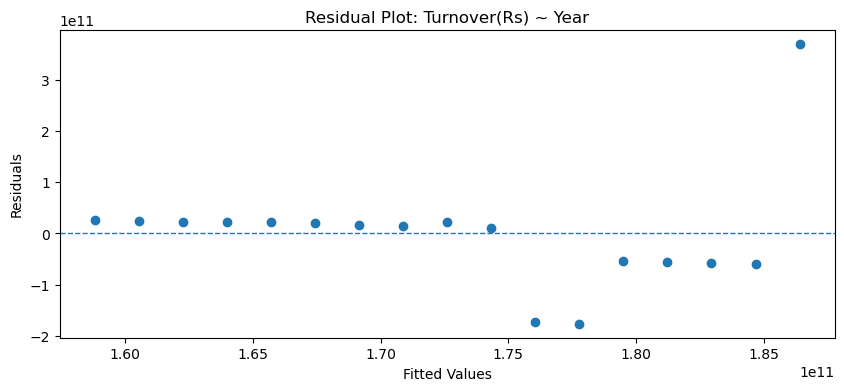

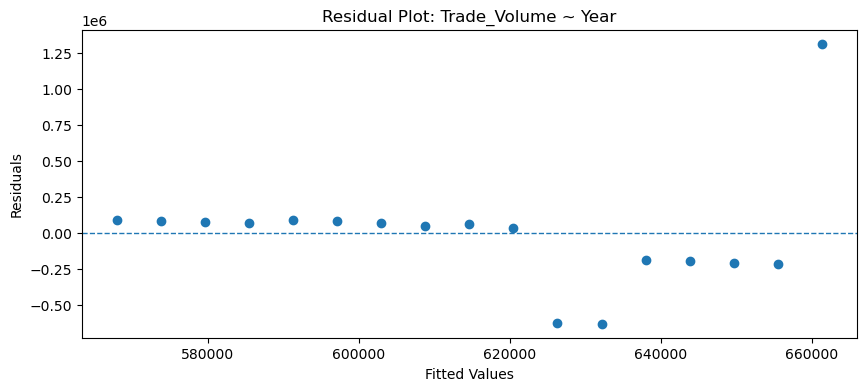

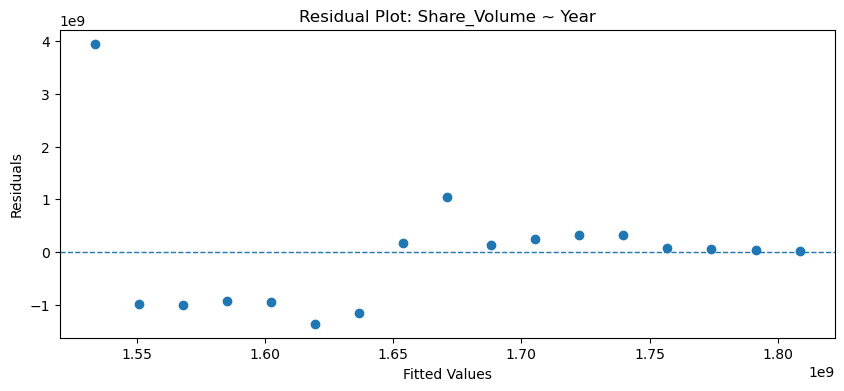

In [105]:
#Model Evaluation – Residual Analysis
for var in variables:
    X = sm.add_constant(company_df4["Year"])
    y = company_df4[var]
    model = sm.OLS(y, X).fit()

    plt.figure(figsize=(10,4))
    plt.scatter(model.fittedvalues, model.resid)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot: {var} ~ Year")
    plt.show()

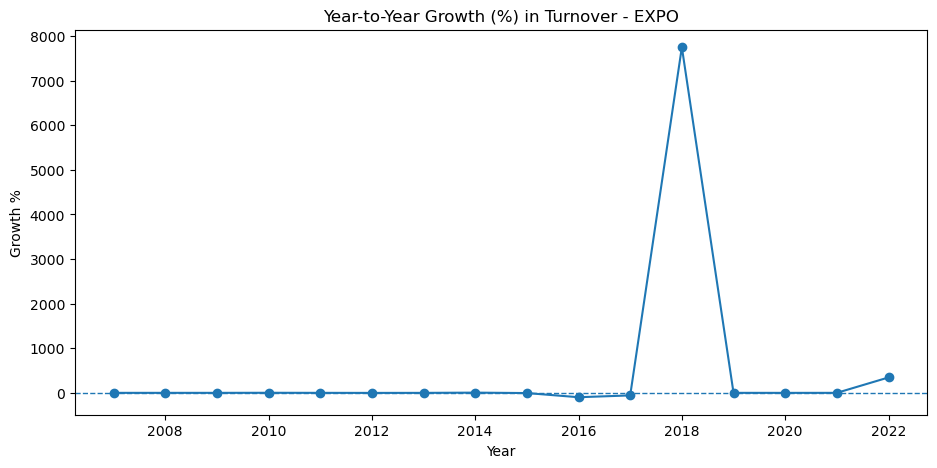

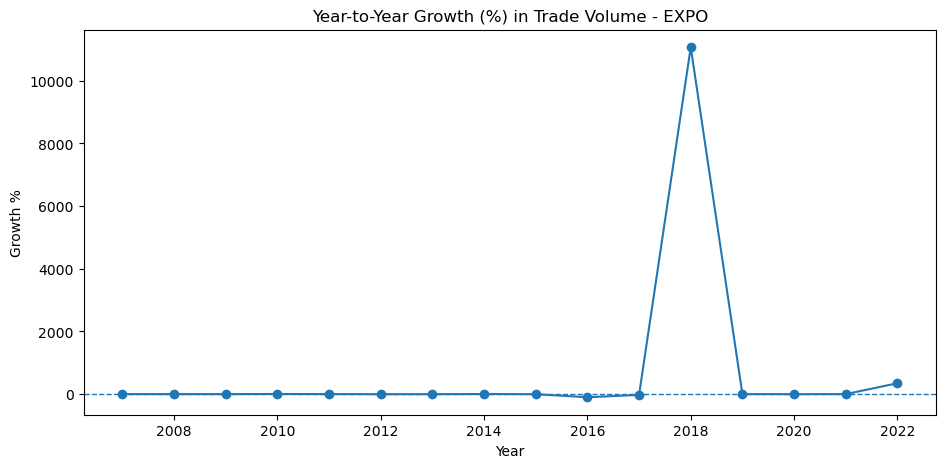

In [106]:
#Growth rate analysis(Innovative Approach)
company_df4["Trade_Volume_Growth_%"] = (
    company_df4["Trade_Volume"].pct_change() * 100
)

plt.figure(figsize=(11, 5))
plt.plot(company_df4["Year"], company_df4["Turnover_Growth_%"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Year-to-Year Growth (%) in Turnover - EXPO")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(company_df4["Year"],company_df4["Trade_Volume_Growth_%"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Year-to-Year Growth (%) in Trade Volume - EXPO")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.show()

In [107]:
#Period Comparison Analysis
#Mann–Whitney U test (Two-sample non-parametric test)

'''Null Hypothesis (H₀) :There is no statistically significant difference in the median annual trading indicator (e.g., turnover) between the two sub-periods.
   Alternative Hypothesis (H₁) :There is a statistically significant difference in the median annual trading indicator between the two sub-periods.'''

'Null Hypothesis (H₀) :There is no statistically significant difference in the median annual trading indicator (e.g., turnover) between the two sub-periods.\n   Alternative Hypothesis (H₁) :There is a statistically significant difference in the median annual trading indicator between the two sub-periods.'

In [108]:
# Define sub-periods
# Define sub-periods
company_df4["Period"] = company_df4["Year"].apply(
    lambda x: "2006–2015" if x <= 2015 else "2016–2022"
)

In [109]:
period_1 = company_df4[company_df4["Period"] == "2006–2015"]["Turnover(Rs)"].dropna()
period_2 = company_df4[company_df4["Period"] == "2016–2022"]["Turnover(Rs)"].dropna()

In [110]:
#Apply Mann–Whitney U Test

from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    period_1,
    period_2,
    alternative="two-sided"
)

print("Mann–Whitney U statistic:", u_stat)
print("p-value:", p_value)

Mann–Whitney U statistic: 60.0
p-value: 0.014401972890686614


In [111]:
#Decision Rule
#alpha = 0.05

'''If     p_value < alpha  , Reject H₀: Significant difference between periods (structural change detected).
   else:   Fail to reject H₀: No significant difference between periods.'''


'If     p_value < alpha  , Reject H₀: Significant difference between periods (structural change detected).\n   else:   Fail to reject H₀: No significant difference between periods.'